<a href="https://colab.research.google.com/github/saitejakchintaginjal/AIML-Projects/blob/main/Renewind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ReneWind — Wind Turbine Failure Prediction

**Summary:** Classification models predicting wind turbine generator failures from sensor data, enabling proactive maintenance and reduced downtime/repair costs.

**Skills & Tools:** EDA, Data Preprocessing, Neural Networks, Classification, Activation Functions

# Import Libraries

In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

import random

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
tf.__version__

'2.20.0'

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Train.csv')

# Data Overview

In [ ]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [ ]:
data.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,8.868415,1.717155,1.357838,-1.777135,0.709780,4.944939,-3.100454,-1.199228,-1.084629,-0.365044,3.131175,-3.948103,-3.578469,-8.139067,-1.936861,-1.327691,-0.402688,-1.734796,9.996461,6.955367,-3.938493,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,-2.094760,-1.525834,0.071573,-3.540142,-2.762006,-10.632206,-0.495236,1.720074,3.871596,-1.209610,-8.222073,2.120866,-5.491808,1.452340,1.450002,3.684654,1.076760,-0.384175,-0.838593,-0.748275,-1.088553,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,-3.781972,2.180042,6.111780,1.984747,-8.330002,-1.639184,-0.914960,5.672348,-3.924200,2.133196,-4.502031,2.777178,5.727949,1.619818,-1.699691,-0.041882,-2.923094,-2.760158,-2.253766,2.552033,0.981858,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,1.583029,3.571478,9.226573,2.553587,-7.039109,-0.993573,-9.664938,1.155224,3.876895,3.523634,-7.015329,-0.132037,-3.446179,-4.801443,-0.875727,-3.811854,5.422077,-3.732322,0.608811,5.256460,1.914766,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,-9.589075,3.176560,1.054517,-1.415882,-4.668611,-5.405377,3.719759,2.892923,2.328591,1.457704,-6.428543,1.818232,0.805897,7.786026,0.330857,5.257424,-4.867417,-0.818941,-5.667393,-2.860975,4.674280,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


Dataset Shape

In [ ]:
data.shape

(20000, 41)

In [ ]:
print(f"Number of Rows    : {data.shape[0]}")
print(f"Number of Columns : {data.shape[1]}")

Number of Rows    : 20000
Number of Columns : 41


**Observation**

- The dataset contains 20000 observations.
- There are 41 features including the target variable.

Dataset Information

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

**Observations**
* The dataset has 20,000 rows and 41 columns.
* There are 40 numerical input features (V1–V40) and 1 target column (Target).
* V1 has 18 missing values; all other columns have no missing values.
* All input features are of float64 type, while the target is int64.
* The dataset is clean overall and suitable for further preprocessing and model building.

Statistical Summary

In [ ]:
data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,-1.895393,1.604825,1.580486,-0.950632,-2.414993,-2.925225,-0.134261,1.189347,1.181808,0.023608,-3.611252,0.951835,-0.366116,1.134389,-0.002186,1.873785,-0.612413,-0.883218,-0.985625,-0.015534,0.486842,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,3.124322,2.930454,2.874658,1.789651,3.354974,4.221717,3.345462,2.592276,3.396925,3.669477,3.567690,1.651547,4.031860,3.912069,2.016740,3.435137,4.368847,1.917713,2.684365,3.005258,3.461384,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,-14.832058,-12.948007,-13.228247,-7.738593,-16.416606,-20.374158,-14.091184,-11.643994,-13.491784,-13.922659,-17.956231,-10.122095,-14.866128,-16.387147,-8.228266,-11.834271,-14.904939,-9.269489,-12.579469,-14.796047,-13.722760,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,-3.922404,-0.396514,-0.223545,-2.170741,-4.415322,-5.634240,-2.215611,-0.403917,-1.050168,-2.432953,-5.930360,-0.118127,-3.098756,-1.468062,-1.365178,-0.337863,-3.652323,-2.171218,-2.787443,-1.867114,-1.817772,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,-1.921237,1.507841,1.637185,-0.957163,-2.382617,-2.682705,-0.014580,0.883398,1.279061,0.033415,-3.532888,0.974687,-0.262093,0.969048,0.025050,1.950531,-0.884894,-0.891073,-1.176181,0.184346,0.490304,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,0.118906,3.571454,3.459886,0.270677,-0.359052,-0.095046,2.068751,2.571770,3.493299,2.512372,-1.265884,2.025594,2.451750,3.545975,1.397112,4.130037,2.189177,0.375884,0.629773,2.036229,2.730688,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,11.826433,15.080698,15.419616,5.670664,12.246455,13.583212,16.756432,13.179863,13.237742,16.052339,13.840473,7.409856,14.458734,17.163291,8.223389,16.836410,17.560404,6.527643,10.722055,12.505812,17.255090,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


**Observations**
* Most features have 20,000 observations; only V1 and V2 has 19,982 due to missing values.
* The feature values have different ranges and scales, so feature scaling/normalization will be required before training the neural network.
* The Target column is binary (0 and 1), indicating a binary classification problem.
* Some features have negative values, which is normal for numerical data.
* Overall, the dataset is clean except for the missing values in V1 and V2.

Missing values

In [ ]:
missing_values = data.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
V1,18
V2,18


Observation
* V1 and V2 each contain 18 missing values.
* All other columns have no missing values.
* The amount of missing data is very small, so it can be handled easily using an appropriate imputation method (e.g., mean or median).

Duplicate Values

In [ ]:
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


The dataset does not contain any duplicate records.

Check Target Variable

In [ ]:
data.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31',
       'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40',
       'Target'],
      dtype='object')

### Before Treating Missing Values

Let's first understand the missing values.

In [ ]:
missing_df = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing Percentage": (data.isnull().sum()/len(data))*100
})

missing_df[missing_df["Missing Count"]>0]

,Missing Count,Missing Percentage
V1,18,0.09
V2,18,0.09


**Observation**

- Only V1 and V2 contain missing values.
- Both columns have only 18 missing values, representing less than 0.1% of the dataset.
- Since the percentage of missing values is very small, imputing them is preferable to dropping observations.

###Treat Missing Values

Before deciding mean or median, let's inspect the distributions.

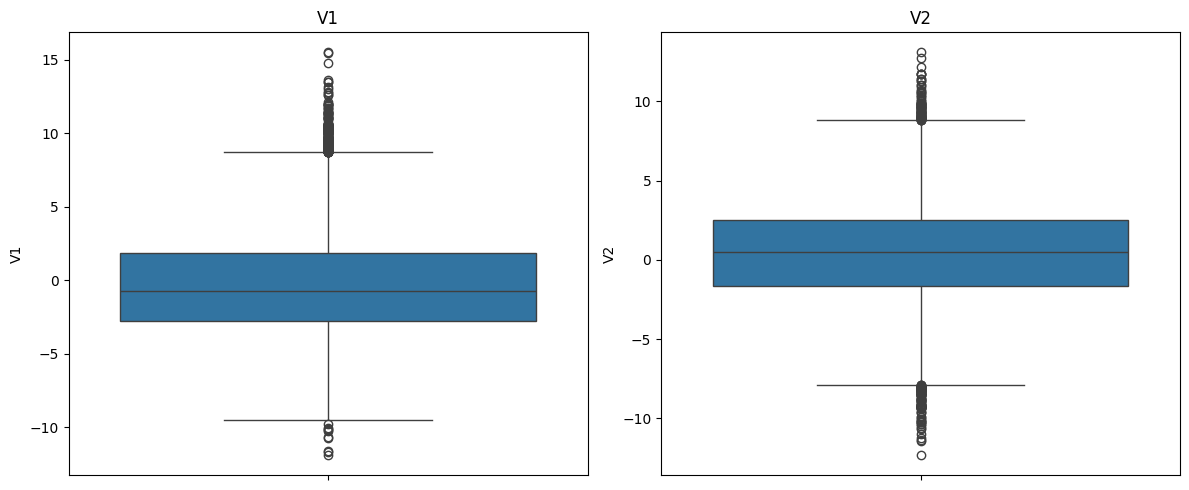

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=data["V1"], ax=axes[0])
axes[0].set_title("V1")

sns.boxplot(y=data["V2"], ax=axes[1])
axes[1].set_title("V2")

plt.tight_layout()
plt.show()

In [ ]:
data[["V1","V2"]].skew()

,0
V1,0.545156
V2,-0.039034



V1 Skewness = 0.545 → Slightly positively skewed with several outliers.

V2 Skewness = -0.039 → Nearly symmetric but also contains outliers.

Since both variables contain noticeable outliers, using the median is the better choice because it is more robust to extreme values.

In [ ]:
# Fill missing values using median
data["V1"].fillna(data["V1"].median(), inplace=True)
data["V2"].fillna(data["V2"].median(), inplace=True)

# Verify
data.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observation**

- V1 and V2 contained a very small number of missing values.
- Since both features contain outliers, the missing values were imputed using the median, which is more robust than the mean.
- After imputation, there are no missing values remaining in the dataset.

## Exploratory Data Analysis (EDA)

**Target Variable Distribution**



Before building a classification model, it is important to understand the distribution of the target variable.

The target variable represents whether a wind turbine generator has failed (`1`) or not (`0`). Examining its distribution helps determine if the dataset is balanced or imbalanced.

If one class is significantly underrepresented, a model trained to maximize accuracy may become biased toward the majority class. In such situations, additional techniques such as class weights or specialized evaluation metrics may be required.

Since the business objective is to detect generator failures before they occur, understanding the class distribution is essential for selecting an appropriate evaluation metric.

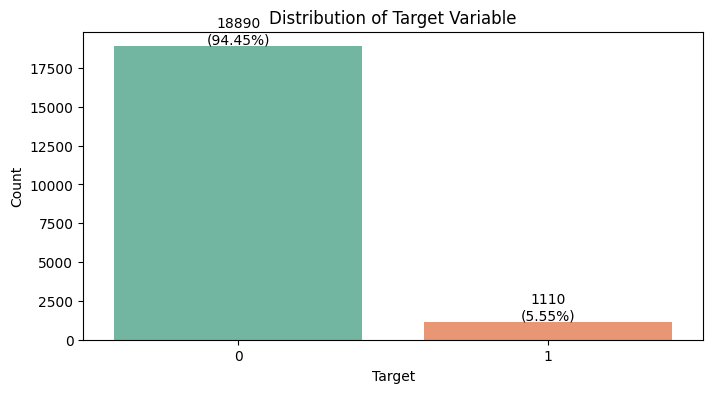

In [ ]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x="Target", data=data, palette="Set2")

total = len(data)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f'{count}\n({percentage:.2f}%)',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

**Observation**

- The target variable is highly imbalanced.
- Approximately **94.45%** of the observations correspond to **non-failure** cases, while only **5.55%** represent **generator failures**.
- Since failure cases are rare, a model that predicts every observation as "No Failure" would achieve high accuracy but would fail to identify actual failures.
- Therefore, **accuracy alone is not an appropriate evaluation metric** for this problem. Greater emphasis should be placed on **Recall** for the failure class, as missing a failure (False Negative) results in significantly higher replacement costs than performing an unnecessary inspection.

**Feature Distribution Analysis**

Understanding the distribution of numerical features helps identify whether variables are normally distributed, skewed, or contain extreme values.

Neural networks generally perform better when numerical features are scaled. Examining the feature distributions helps determine whether preprocessing such as normalization or standardization will be required before training.

Instead of plotting 40 individual histograms, we'll create one clean visualization.

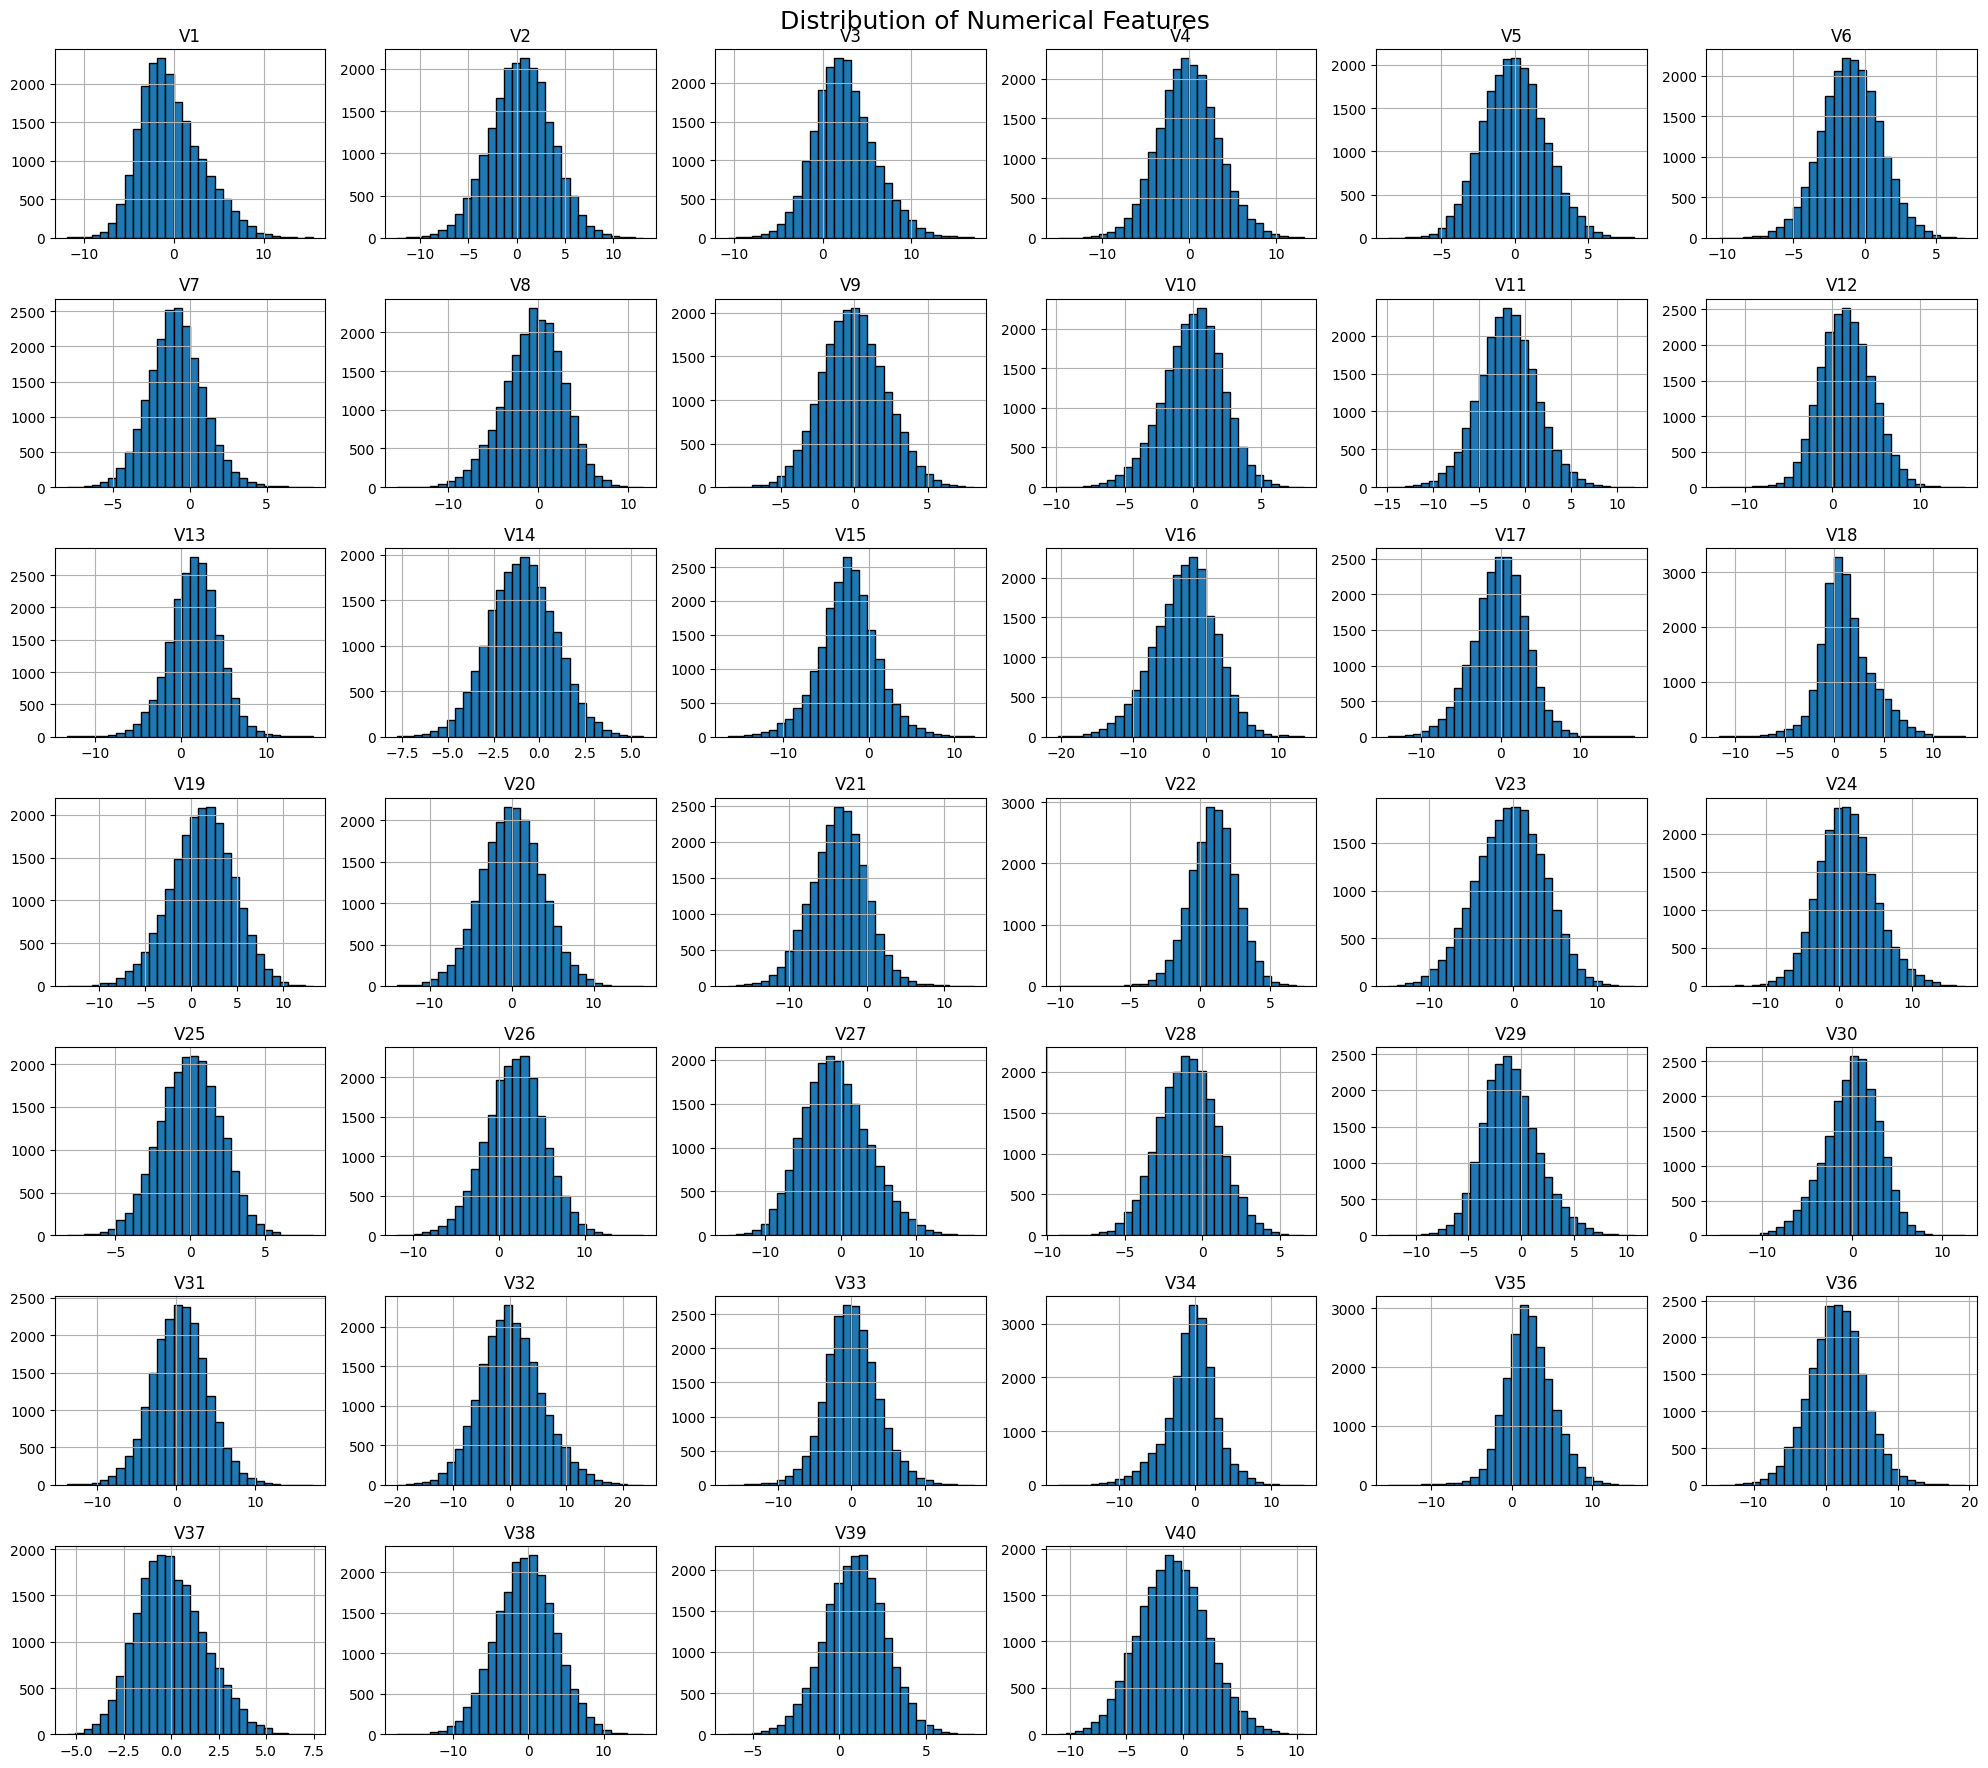

In [ ]:
data.drop("Target",axis=1).hist(
    bins=30,
    figsize=(20,18),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features",
             fontsize=18)

plt.tight_layout()

plt.show()

Observation

Most sensor variables exhibit continuous distributions with varying degrees of skewness. Several features also show long tails, indicating that feature scaling will be beneficial before training the neural network.

**Outlier Analysis**

Outlier analysis helps identify observations that lie far from the majority of the data.

For sensor-based datasets, extreme values do not necessarily indicate data errors. Instead, they may represent abnormal operating conditions or early signs of equipment degradation.

Therefore, before deciding whether to remove outliers, it is important to examine their presence and assess whether they are likely to contain meaningful information related to generator failures.

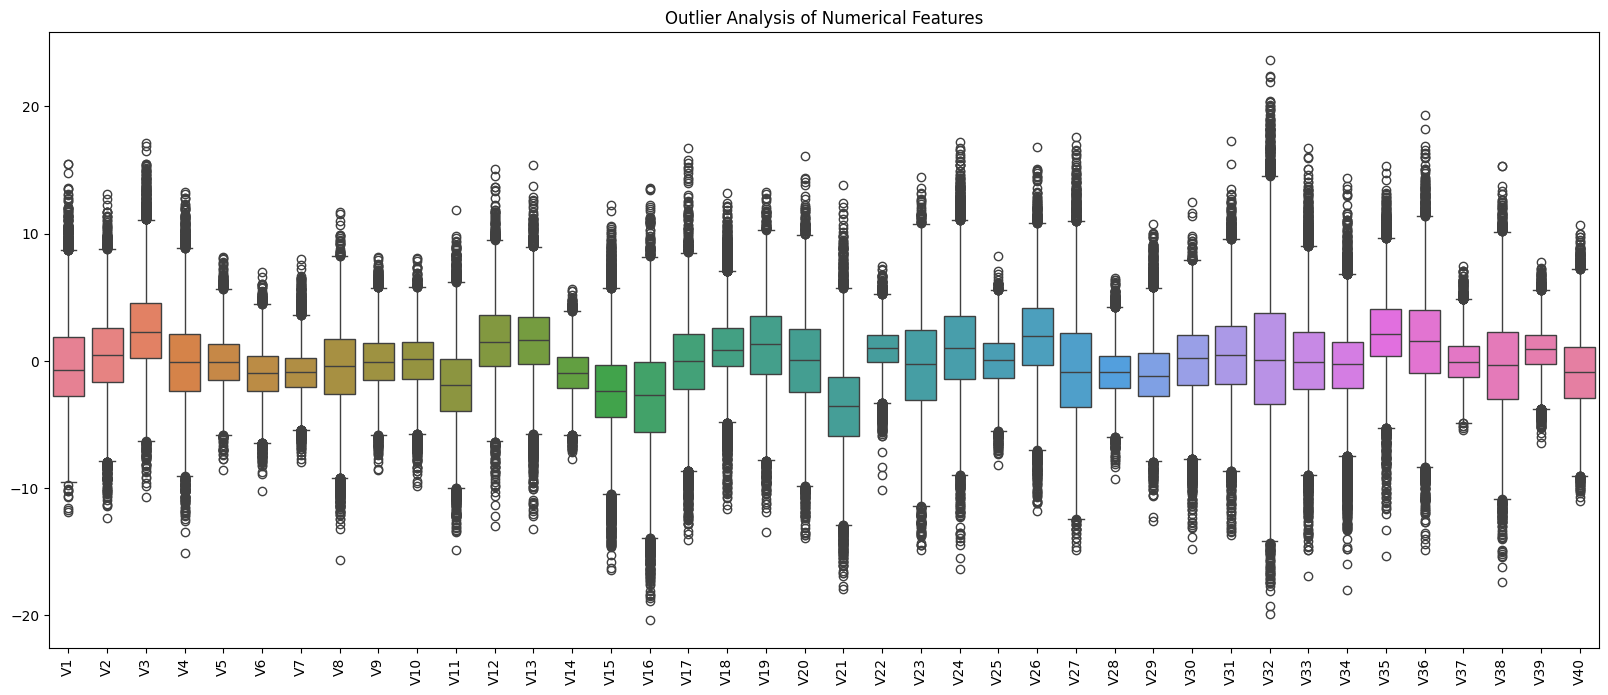

In [ ]:
plt.figure(figsize=(20,8))

sns.boxplot(data=data.drop("Target",axis=1))

plt.xticks(rotation=90)

plt.title("Outlier Analysis of Numerical Features")

plt.show()

**Observation**

- Most numerical features contain outliers, with varying degrees of spread across the sensor variables.
- Features such as **V3, V16, V24, V27, V32, V35, and V36** exhibit a relatively larger number of extreme observations compared to other variables.
- Since this dataset consists of wind turbine sensor measurements, these extreme values may represent abnormal operating conditions or impending generator failures rather than incorrect measurements.
- Therefore, the outliers are retained, as removing them could result in the loss of valuable information required for predicting failures.
- Additionally, Artificial Neural Networks are generally less sensitive to outliers than distance-based algorithms, especially after appropriate feature scaling.

> **Why are outliers not removed?**
>
> In this project, the objective is to predict generator failures using sensor data. Extreme sensor readings may correspond to genuine fault conditions rather than erroneous observations. Removing these values could reduce the model's ability to learn failure patterns. Therefore, the outliers are retained and the features will be standardized before training the neural network.

In [ ]:
# Percentage of outliers in each feature using the IQR method

outlier_percentage = {}

for col in data.drop("Target", axis=1).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_percentage[col] = round((len(outliers) / len(data)) * 100, 2)

outlier_df = (
    pd.DataFrame.from_dict(outlier_percentage, orient="index", columns=["Outlier (%)"])
    .sort_values("Outlier (%)", ascending=False)
)

outlier_df.head(10)

,Outlier (%)
V34,4.01
V18,3.65
V15,2.56
V33,1.92
V29,1.68
V35,1.57
V24,1.54
V13,1.52
V17,1.48
V7,1.46



### Correlation Analysis

Correlation analysis helps identify the strength of linear relationships among sensor variables.

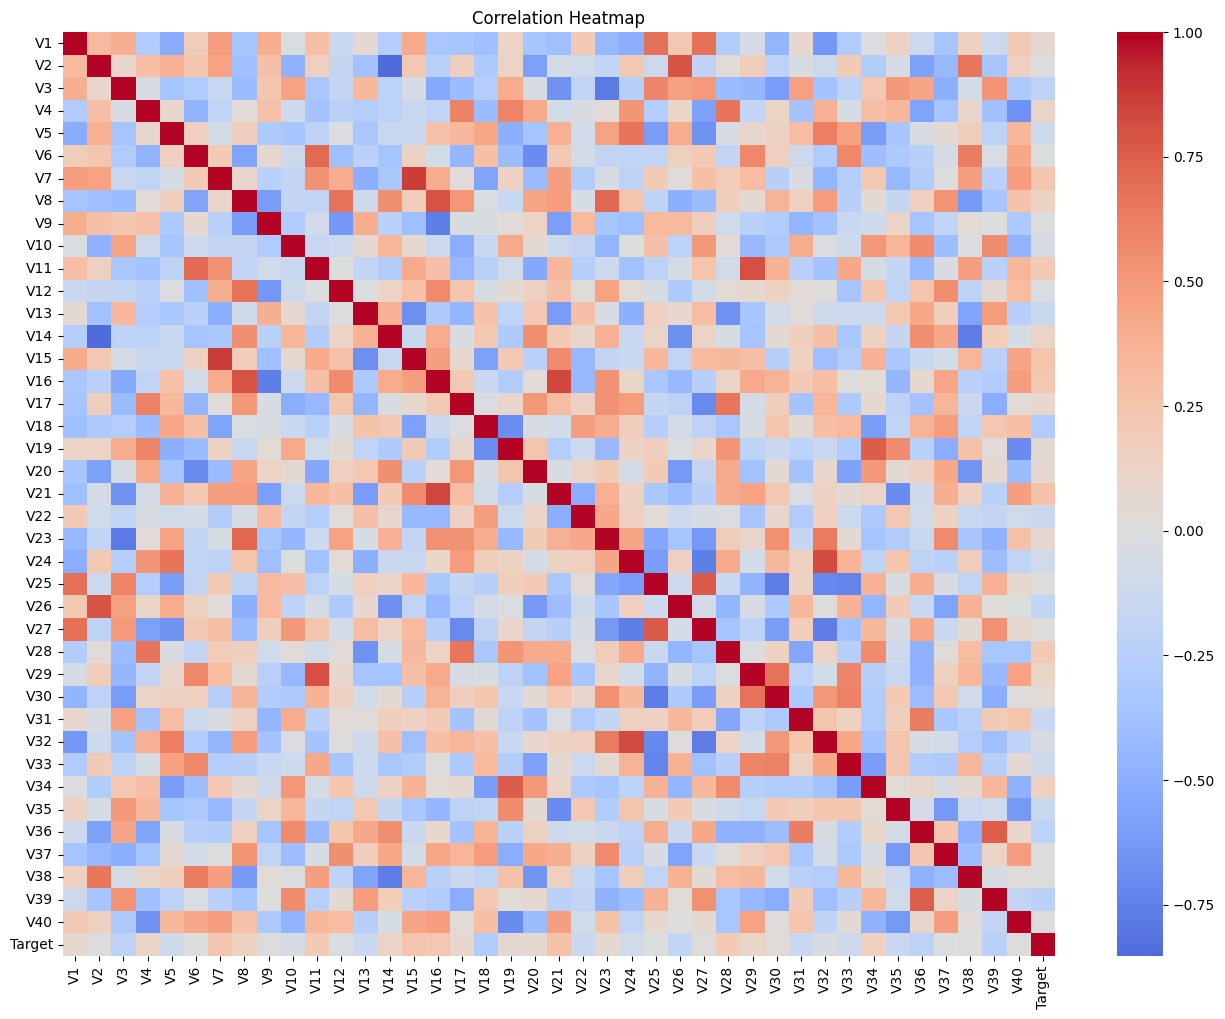

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    data.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

**Select Top Correlated Features**

In [ ]:
# Top 10 features most correlated with the target
top_features = (
    data.corr()["Target"]
    .abs()
    .sort_values(ascending=False)
    .index[:11]       # Target + Top 10 features
)

top_features

Index(['Target', 'V18', 'V21', 'V15', 'V7', 'V16', 'V39', 'V36', 'V3', 'V28',
       'V11'],
      dtype='object')

**Correlation Heatmap of Top Features**

To improve interpretability, we selected the features with the strongest correlation to the target variable and examined the relationships among them.

This helps identify whether important features are highly correlated with each other, which provides insight into the underlying sensor measurements and their interactions.

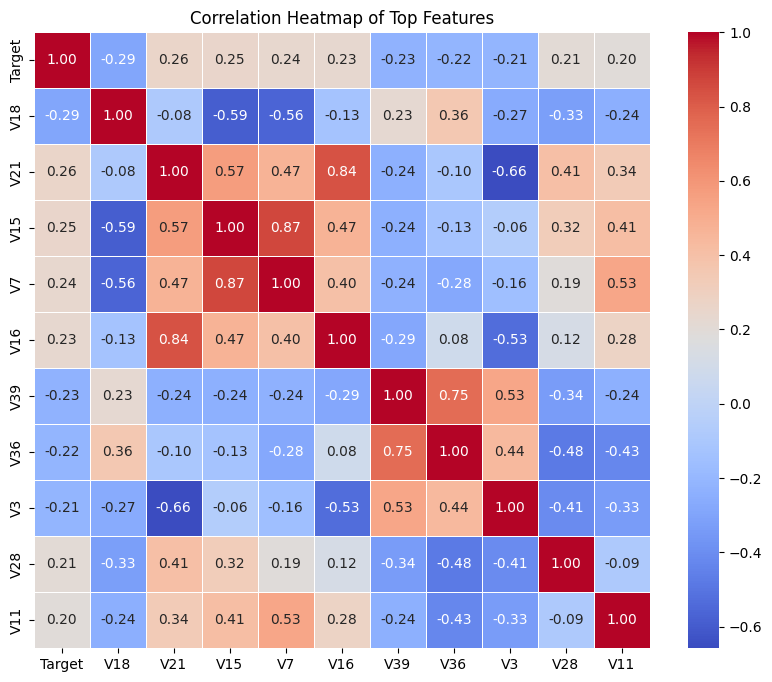

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Top Features")

plt.show()

**Observation**

- The selected features exhibit low to moderate correlations with the target variable, with correlation coefficients ranging approximately between **-0.29 and 0.26**.
- Some feature pairs, such as **V15–V7 (0.87)**, **V21–V16 (0.84)**, and **V39–V36 (0.75)**, show strong positive correlations, indicating that these sensor measurements may capture similar operating characteristics.
- Strong negative correlations are also observed between a few feature pairs, such as **V21–V3 (-0.66)** and **V18–V15 (-0.59)**.
- Since the project uses an Artificial Neural Network, these correlated features are retained, as neural networks can effectively learn from correlated inputs without requiring feature removal.

**Feature Correlation with Target**

The correlation of each feature with the target variable is examined to identify the sensor variables that have the strongest linear relationship with generator failures.

Although correlation alone does not determine feature importance, it provides an initial understanding of which variables may contribute more towards predicting failures.

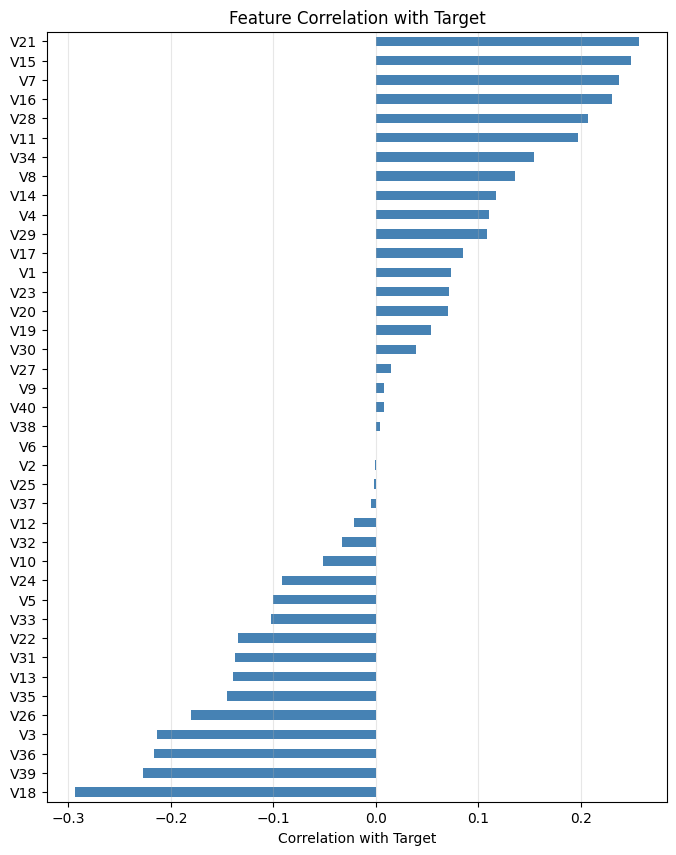

In [ ]:
target_corr = (
    data.corr()["Target"]
    .drop("Target")
    .sort_values()
)

plt.figure(figsize=(8,10))

target_corr.plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Correlation with Target")
plt.title("Feature Correlation with Target")

plt.grid(axis="x", alpha=0.3)

plt.show()

**Observation**

- No individual feature shows a very strong linear correlation with the target variable, with the highest absolute correlation being approximately **0.29**.
- Features such as **V21, V15, V7, V16, V28, and V11** exhibit the strongest positive correlation with generator failures.
- Features including **V18, V39, V36, V3, V26, and V35** show relatively stronger negative correlations with the target.
- The generally low correlation values suggest that generator failures are unlikely to be explained by a single sensor measurement. Instead, the prediction is expected to depend on the combined interaction of multiple sensor variables.
- This supports the use of an Artificial Neural Network, which is capable of learning complex, non-linear relationships among multiple features.

### Bivariate Analysis: Feature Distribution by Target Class

To better understand how the most relevant sensor features behave across the two target classes, violin plots are used for the features having the highest correlation with the target variable.

A violin plot combines the information provided by a box plot and a density plot, allowing us to compare the distribution, median, spread, and variability of each feature for generator failure and non-failure cases.

This helps identify whether the selected sensor variables exhibit distinct patterns that may assist the neural network in distinguishing between the two classes.

Now we compare the target with the most informative features.

Instead of randomly selecting V1–V6, we'll select the top six features most correlated with the target.

In [ ]:
top_features = (
    data.corr()["Target"]
    .abs()
    .sort_values(ascending=False)
    .index[1:7]
)

top_features

Index(['V18', 'V21', 'V15', 'V7', 'V16', 'V39'], dtype='object')

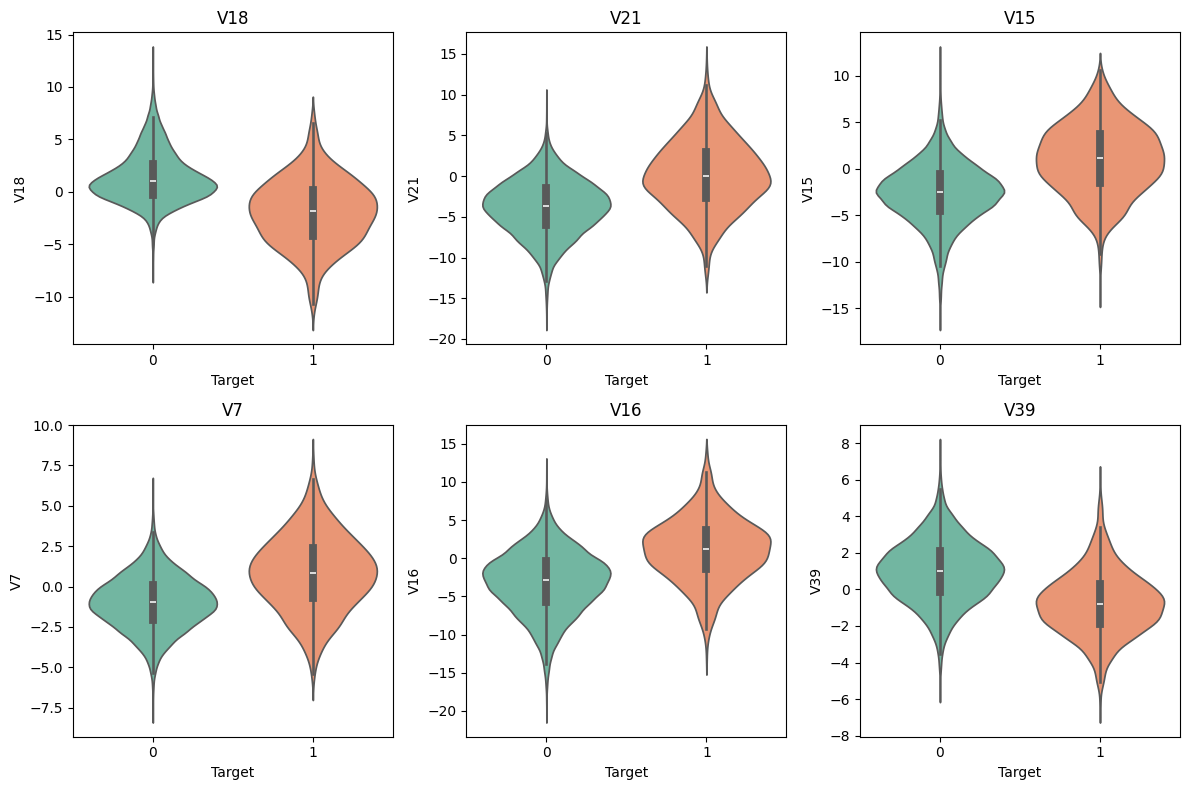

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for feature, ax in zip(top_features, axes.flatten()):

    sns.violinplot(
        x="Target",
        y=feature,
        data=data,
        ax=ax,
        palette="Set2"
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

**Observation**

- The selected features exhibit noticeable differences in their distributions between the failure (`Target = 1`) and non-failure (`Target = 0`) classes.
- Features **V21, V15, V7, and V16** tend to have higher values for failure cases compared to non-failure cases, indicating a positive relationship with generator failure.
- Conversely, features **V18** and **V39** generally show lower values for failure cases, suggesting a negative relationship with the target variable.
- Although there is some overlap between the two classes, the shift in the distributions indicates that these features contain useful information for distinguishing generator failures.
- Since no single feature completely separates the two classes, the prediction of failures is expected to rely on the combined effect of multiple sensor variables, reinforcing the suitability of using an Artificial Neural Network to learn these complex relationships.

# Data Preprocessing



Before training the neural network, the dataset is prepared by separating the predictor variables from the target variable.

The predictor variables (`X`) consist of the 40 anonymized sensor features, while the target variable (`y`) indicates whether a generator failure has occurred.

###**Separate features and target**

####Training Data

In [ ]:
X = data.drop("Target", axis=1)
y = data["Target"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (20000, 40)
Target Vector Shape  : (20000,)


**Observations**
* The training dataset contains 20,000 samples and 40 input features.
* The Target column has been separated from the input features for training datasets.
* The datasets have number of features (40), making them ready for model training and evaluation.

###**Train-Validation Split**

The dataset is 80:20 split into training, validation sets.

* 80% training → sufficient data for learning.
* 20% validation → reliable model selection.
* The independent test set remains untouched for final evaluation.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [ ]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (16000, 40)
Validation: (4000, 40)


Observations
* The training data is split into 80% training (16,000 samples) and 20% validation (4,000 samples).
* Stratified splitting is used to maintain the same class distribution in both sets.
* The test set (5,000 samples) is kept separate for final model evaluation.
* All datasets contain the same 40 input features, ensuring consistency during training and testing.

###**Prevent Data Leakage**

## Feature Scaling

Artificial Neural Networks are sensitive to the scale of input features. Therefore, StandardScaler is used to standardize the numerical features.

To prevent data leakage, the scaler is fitted only on the training data. The same fitted scaler is then used to transform the validation and test datasets.

This ensures that information from the validation and test sets does not influence the model during training.

In [ ]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_val_scaled = scaler.transform(X_val)

**Observation**

- The dataset has been divided into training and validation sets using stratified sampling to preserve the class distribution.
- StandardScaler was fitted only on the training data and then applied to the validation and test datasets.
- This preprocessing approach prevents data leakage and ensures an unbiased evaluation of the neural network.

Since we already have an independent test set, there's no need to reserve additional data for testing from the training set.

Using 80:20,

* Gives the model more training data (16,000 samples).
* Still leaves 4,000 validation samples for tuning.
* Keeps the separate 5,000-row test dataset for the final evaluation.

# Model Building

### Choosing the Evaluation Metric

Selecting an appropriate evaluation metric is crucial for this business problem.

The dataset is highly imbalanced, with only **5.55%** of the observations representing generator failures. In such cases, accuracy alone can be misleading because a model predicting every observation as "No Failure" would still achieve a very high accuracy while failing to detect actual failures.

From a business perspective:

- **True Positive (TP):** Correctly predicts a generator failure, allowing preventive repair.
- **False Positive (FP):** Incorrectly predicts a failure, resulting in an unnecessary inspection.
- **False Negative (FN):** Fails to identify an actual generator failure, leading to costly replacement and downtime.

Since the cost of a **False Negative** is significantly higher than the cost of a False Positive, the primary objective is to maximize the detection of actual failures.

Therefore, **Recall** is selected as the primary evaluation metric, while Precision, F1-score, Accuracy, and ROC-AUC are also monitored to obtain a comprehensive assessment of model performance.

### Build Baseline ANN

Build a Neural Network model with SGD as optimizer

No Additional Hidden Layers.

No Dropout.

No ClassWeights.

Those will be introduced later.

### Building the Baseline Neural Network

A baseline Artificial Neural Network (ANN) is developed using the Stochastic Gradient Descent (SGD) optimizer, as specified in the project rubric.

The model consists of:

- Input layer
- Two hidden layers with ReLU activation
- Output layer with Sigmoid activation for binary classification

The Binary Crossentropy loss function is used because the task involves predicting one of two classes (Failure or No Failure).

In [ ]:
tf.random.set_seed(42)

baseline_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(

    optimizer=SGD(
        learning_rate=0.01
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]

)

In [ ]:
history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1

)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9880 - auc: 0.9553 - loss: 0.0568 - precision: 0.9820 - recall: 0.7984 - val_accuracy: 0.9895 - val_auc: 0.9476 - val_loss: 0.0563 - val_precision: 0.9688 - val_recall: 0.8378
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - auc: 0.9554 - loss: 0.0560 - precision: 0.9834 - recall: 0.8029 - val_accuracy: 0.9900 - val_auc: 0.9480 - val_loss: 0.0555 - val_precision: 0.9691 - val_recall: 0.8468
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - auc: 0.9553 - loss: 0.0554 - precision: 0.9836 - recall: 0.8097 - val_accuracy: 0.9900 - val_auc: 0.9482 - val_loss: 0.0549 - val_precision: 0.9691 - val_recall: 0.8468
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9887 - auc: 0.9554 - loss: 0.0547 - precision: 0.9836 - recall: 0.8097 - val_accuracy: 0.9902 - val_auc: 0.9488 - val_loss: 0.0543 - val_precision: 0.9645 - val_recall: 0.8559
Epoch 5/20
500/500 ━━━━━━━━━━━━━

####**Plot Learning Curves**

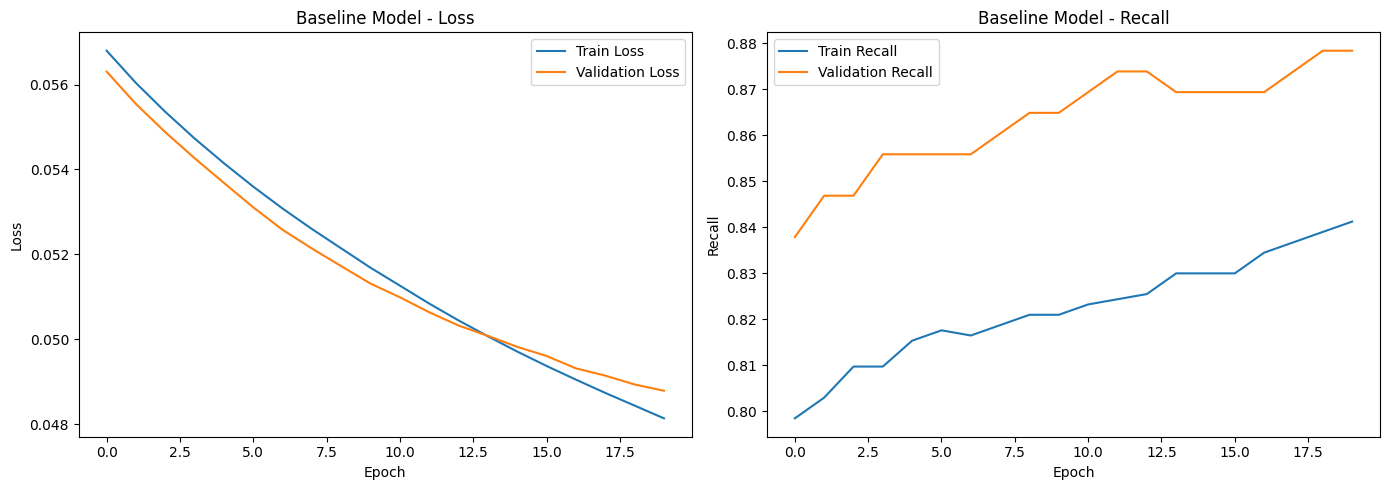

In [ ]:
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.title("Baseline Model - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history_baseline.history["recall"], label="Train Recall")
plt.plot(history_baseline.history["val_recall"], label="Validation Recall")
plt.title("Baseline Model - Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
baseline_model.evaluate(
    X_val_scaled,
    y_val,
    verbose=1
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9910 - auc: 0.9478 - loss: 0.0488 - precision: 0.9559 - recall: 0.8784


[0.0487847626209259,
 0.9909999966621399,
 0.9558823704719543,
 0.8783783912658691,
 0.9477654099464417]

In [ ]:
# Predictions

y_val_prob = baseline_model.predict(X_val)

y_val_pred = (y_val_prob >= 0.45).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Model Evaluation

print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall   : {recall_score(y_val, y_val_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")

Accuracy : 0.9762
Precision: 0.7530
Recall   : 0.8514
F1 Score : 0.7992
ROC AUC  : 0.9461


In [ ]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3778
           1       0.75      0.85      0.80       222

    accuracy                           0.98      4000
   macro avg       0.87      0.92      0.89      4000
weighted avg       0.98      0.98      0.98      4000



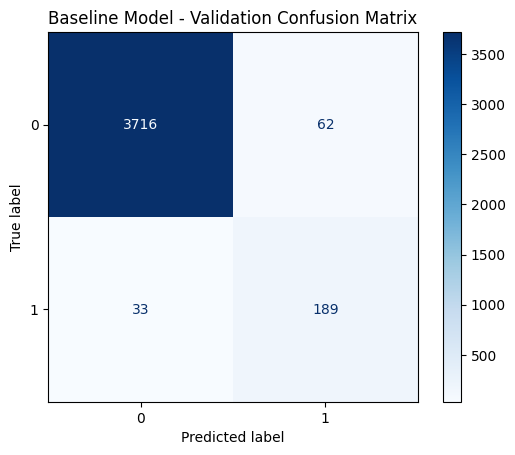

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline Model - Validation Confusion Matrix")

plt.show()

In [ ]:
roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

print(f"ROC AUC Score : {roc_auc:.4f}")

ROC AUC Score : 0.9461


**Baseline Model Observations**

* The baseline model achieved 98% validation accuracy, indicating good overall classification performance.
* It correctly identified 189 out of 222 failures, resulting in a Recall of 82%, meaning most failures were detected, but 33 failures were still missed.
* The model achieved 75% Precision, indicating that most predicted failures were actual failures with relatively few false alarms.
* The confusion matrix shows 62 false positives and 33 false negatives, suggesting there is still room to improve failure detection by reducing missed failures.
* The model achieved a ROC-AUC score of 0.9461, demonstrating good ability to distinguish between failure and non-failure cases.

Business Insight

The baseline model provides a good starting point by detecting most failures, but improving Recall is important to reduce costly generator breakdowns and enhance preventive maintenance.

##Model Performance Improvement and Final Model Selection

Before Building Models

Evaluation Function

We'll use one function for every model.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
def evaluate_model(model, X, y, model_name):

    # Predicted probabilities
    y_prob = model.predict(X, verbose=0)

    # Convert probabilities to class labels
    y_pred = (y_prob >= 0.45).astype(int)

    print(f"\n{'='*60}")
    print(model_name)
    print('='*60)

    print(classification_report(y, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred,
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred),
        "ROC AUC": roc_auc_score(y, y_prob)
    }

    return metrics

**Results Table**

In [ ]:
results_df = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

##**Model 1 - Adam Optimizer**

In Model 1, the optimizer is changed from SGD to Adam, and the learning rate is reduced from 0.01 to 0.001 while keeping the architecture and Early Stopping unchanged. These changes are made to improve convergence, training stability, and overall model performance.

**Build Model**

In [ ]:
tf.keras.backend.clear_session()

tf.random.set_seed(42)

model_1 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [ ]:
history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9943 - auc: 0.9840 - loss: 0.0279 - precision: 0.9914 - recall: 0.9054 - val_accuracy: 0.9920 - val_auc: 0.9591 - val_loss: 0.0466 - val_precision: 0.9524 - val_recall: 0.9009
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9945 - auc: 0.9847 - loss: 0.0276 - precision: 0.9914 - recall: 0.9088 - val_accuracy: 0.9920 - val_auc: 0.9590 - val_loss: 0.0477 - val_precision: 0.9524 - val_recall: 0.9009
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9944 - auc: 0.9849 - loss: 0.0270 - precision: 0.9914 - recall: 0.9077 - val_accuracy: 0.9912 - val_auc: 0.9592 - val_loss: 0.0474 - val_precision: 0.9431 - val_recall: 0.8964
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9944 - auc: 0.9845 - loss: 0.0272 - precision: 0.9914 - recall: 0.9077 - val_accuracy: 0.9918 - val_auc: 0.9601 - val_loss: 0.0475 - val_precision: 0.9522 - val_recall: 0.8964
Epoch 5/50
500/500 ━━━━━━━━━━━━━

**Plot Learning Curves**

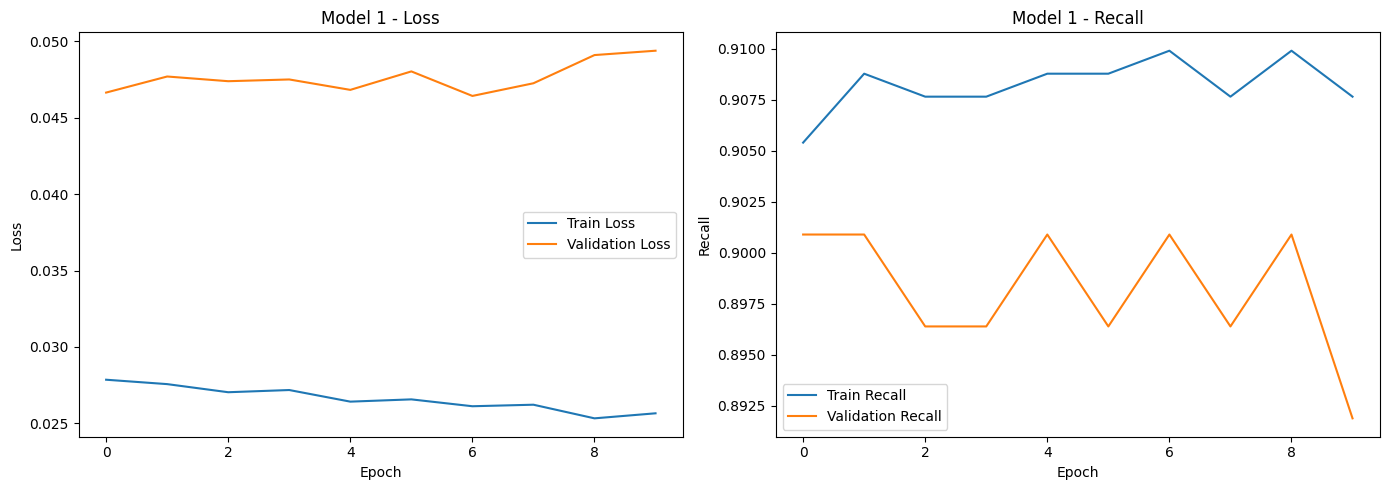

In [ ]:
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_1.history["loss"], label="Train Loss")
plt.plot(history_1.history["val_loss"], label="Validation Loss")
plt.title("Model 1 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history_1.history["recall"], label="Train Recall")
plt.plot(history_1.history["val_recall"], label="Validation Recall")
plt.title("Model 1 - Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**


Model 1 - Adam Optimizer
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3778
           1       0.94      0.91      0.92       222

    accuracy                           0.99      4000
   macro avg       0.97      0.95      0.96      4000
weighted avg       0.99      0.99      0.99      4000



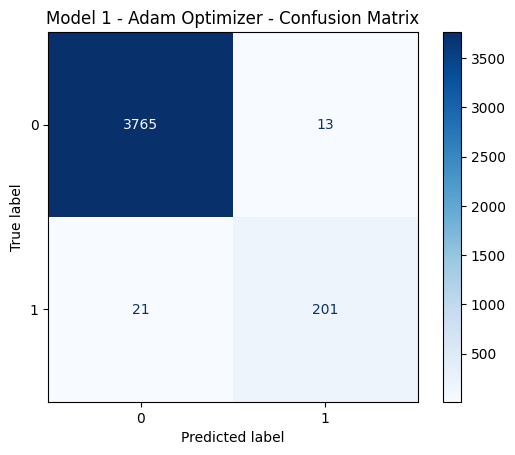

In [ ]:
metrics = evaluate_model(
    model=model_1,
    X=X_val,
    y=y_val,
    model_name="Model 1 - Adam Optimizer"
)

In [ ]:
# Store Results

results_df.loc[len(results_df)] = [
    "Model 1",
    metrics["Accuracy"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["F1 Score"],
    metrics["ROC AUC"]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.9915,0.939252,0.905405,0.922018,0.964776


Observations

* The model achieved 99% validation accuracy, demonstrating excellent overall classification performance.
* It correctly identified 201 out of 222 actual failures, resulting in a Recall of 91%, which is slightly better than the previous model.
* The model achieved 94% Precision, indicating that most predicted failures were actual failures, with very few false alarms.
* The confusion matrix shows only 13 false positives and 21 false negatives, reflecting a strong balance between detecting failures and minimizing unnecessary inspections.
* Overall, the Adam optimizer improved the model's ability to detect failures while maintaining high Precision, making it one of the strongest-performing models.

Business Insights:

The Adam optimizer improved failure detection with very few false alarms, enabling timely preventive maintenance while minimizing unnecessary inspections and costly generator failures.

##**Model 2** : Increased Network Capacity (Additional Hidden Layer)

In this model, an additional hidden layer with 16 neurons is added to increase the model's capacity to learn more complex patterns while keeping the Adam optimizer unchanged.

**Build Model**

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model_2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu",),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [ ]:
history_2 = model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9791 - auc: 0.9359 - loss: 0.0852 - precision: 0.9481 - recall: 0.6588 - val_accuracy: 0.9902 - val_auc: 0.9530 - val_loss: 0.0593 - val_precision: 0.9336 - val_recall: 0.8874
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9899 - auc: 0.9516 - loss: 0.0532 - precision: 0.9727 - recall: 0.8423 - val_accuracy: 0.9898 - val_auc: 0.9510 - val_loss: 0.0565 - val_precision: 0.9249 - val_recall: 0.8874
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9908 - auc: 0.9564 - loss: 0.0475 - precision: 0.9768 - recall: 0.8536 - val_accuracy: 0.9918 - val_auc: 0.9500 - val_loss: 0.0518 - val_precision: 0.9437 - val_recall: 0.9054
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9919 - auc: 0.9622 - loss: 0.0435 - precision: 0.9785 - recall: 0.8727 - val_accuracy: 0.9918 - val_auc: 0.9527 - val_loss: 0.0491 - val_precision: 0.9437 - val_recall: 0.9054
Epoch 5/50
500/500 ━━━━━━━━━━━━━

**Plot Learning Curves**

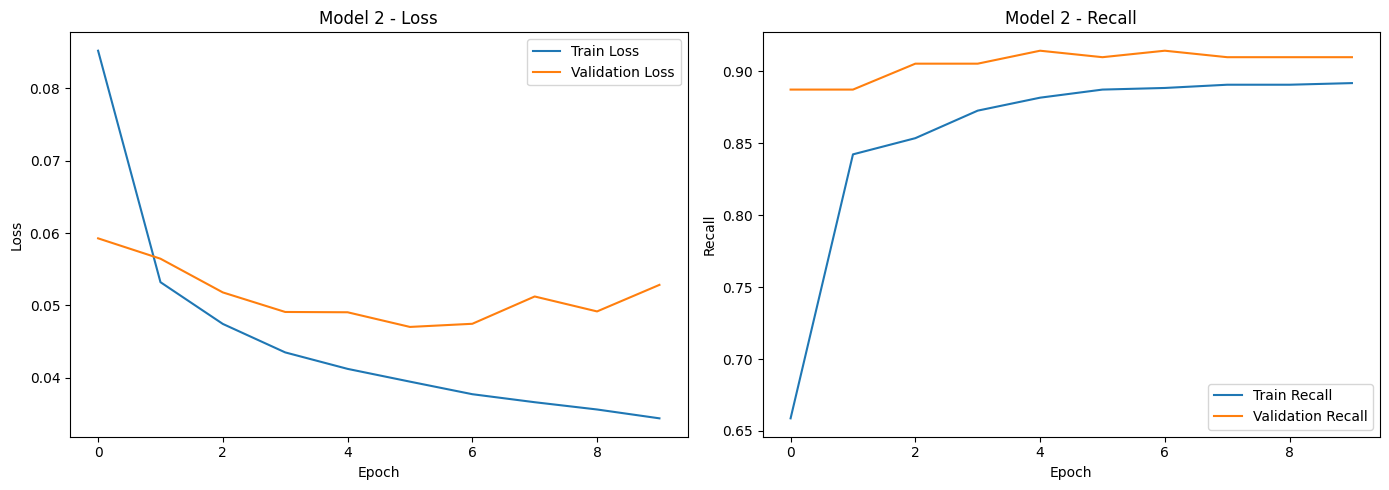

In [ ]:
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_2.history["loss"], label="Train Loss")
plt.plot(history_2.history["val_loss"], label="Validation Loss")
plt.title("Model 2 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history_2.history["recall"], label="Train Recall")
plt.plot(history_2.history["val_recall"], label="Validation Recall")
plt.title("Model 2 - Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**


Model 2 - Additional Hidden Layer
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3778
           1       0.91      0.89      0.90       222

    accuracy                           0.99      4000
   macro avg       0.95      0.94      0.95      4000
weighted avg       0.99      0.99      0.99      4000



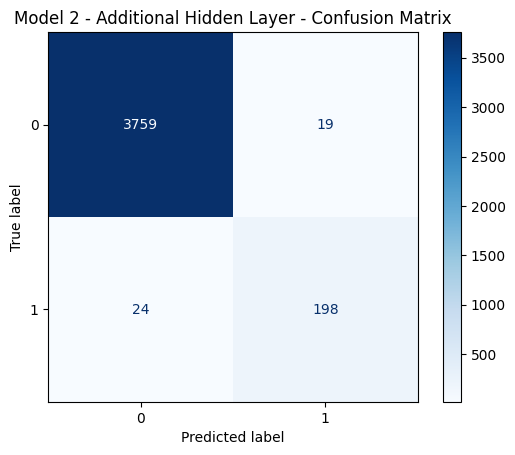

In [ ]:
metrics = evaluate_model(
    model=model_2,
    X=X_val,
    y=y_val,
    model_name="Model 2 - Additional Hidden Layer"
)

In [ ]:
# Store Results

results_df.loc[len(results_df)] = [
    "Model 2",
    metrics["Accuracy"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["F1 Score"],
    metrics["ROC AUC"]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.99150,0.939252,0.905405,0.922018,0.964776
1,Model 2,0.98925,0.912442,0.891892,0.902050,0.947194


In [ ]:
results_df = results_df.iloc[0:0]

Observations

* The model achieved 99% validation accuracy, indicating excellent overall classification performance.
* It correctly identified 198 out of 222 actual failures, resulting in a Recall of 89%, which is slightly lower than Model 1.
* The model achieved 91% Precision, indicating that most predicted failures were actual failures, with a low number of false alarms.
* The confusion matrix shows 19 false positives and 24 false negatives, indicating a slight increase in both false alarms and missed failures compared to Model 1.
* Overall, adding an additional hidden layer did not improve performance and slightly reduced the model's ability to detect failures..

Business Perspective

Adding an additional hidden layer did not provide any significant business benefit, as it slightly increased missed failures and false alarms compared to Model 1, making the Adam optimizer model a better choice.

##**Model 3** : Adam + Dropout

In this model, Dropout layers are added after the hidden layers to reduce overfitting by randomly deactivating neurons during training while keeping the optimizer and architecture unchanged.

**Build Model**

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model_3 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [ ]:
history_3 = model_3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9659 - auc: 0.8969 - loss: 0.1282 - precision: 0.8004 - recall: 0.5146 - val_accuracy: 0.9772 - val_auc: 0.9393 - val_loss: 0.0864 - val_precision: 0.9645 - val_recall: 0.6126
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9771 - auc: 0.9364 - loss: 0.0887 - precision: 0.8896 - recall: 0.6712 - val_accuracy: 0.9855 - val_auc: 0.9468 - val_loss: 0.0658 - val_precision: 0.9767 - val_recall: 0.7568
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9819 - auc: 0.9398 - loss: 0.0806 - precision: 0.9359 - recall: 0.7230 - val_accuracy: 0.9872 - val_auc: 0.9462 - val_loss: 0.0605 - val_precision: 0.9672 - val_recall: 0.7973
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9833 - auc: 0.9445 - loss: 0.0745 - precision: 0.9404 - recall: 0.7466 - val_accuracy: 0.9890 - val_auc: 0.9473 - val_loss: 0.0555 - val_precision: 0.9837 - val_recall: 0.8153
Epoch 5/50
500/500 ━━━━━━━━━━━━━

**Plot Learning Curves**

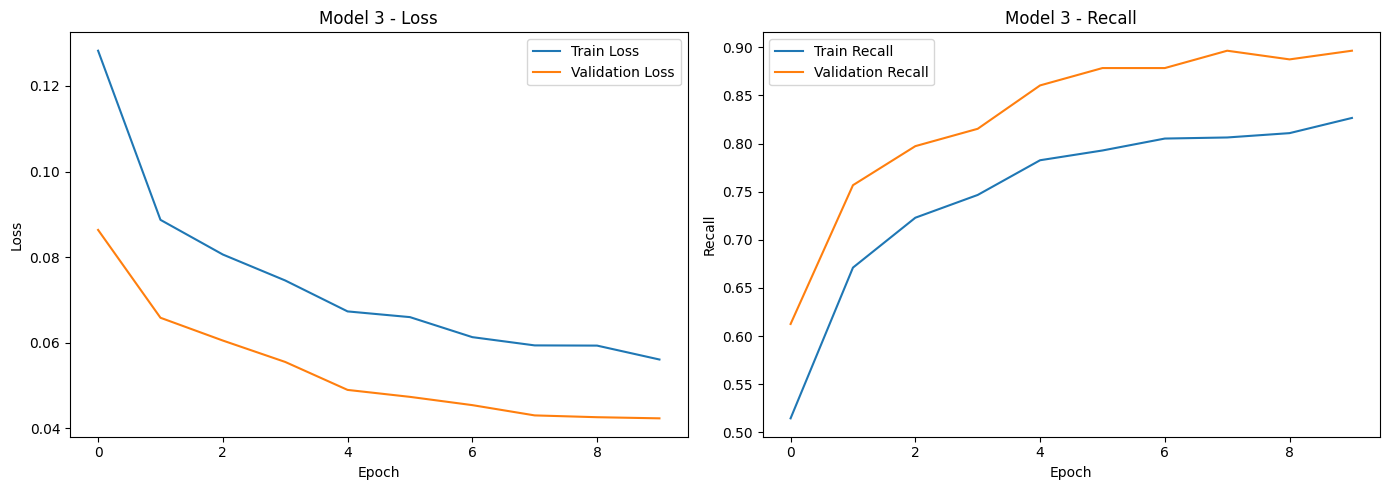

In [ ]:
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_3.history["loss"], label="Train Loss")
plt.plot(history_3.history["val_loss"], label="Validation Loss")
plt.title("Model 3 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history_3.history["recall"], label="Train Recall")
plt.plot(history_3.history["val_recall"], label="Validation Recall")
plt.title("Model 3 - Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**


Model 3 - Adam + Dropout
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3778
           1       0.97      0.64      0.77       222

    accuracy                           0.98      4000
   macro avg       0.97      0.82      0.88      4000
weighted avg       0.98      0.98      0.98      4000



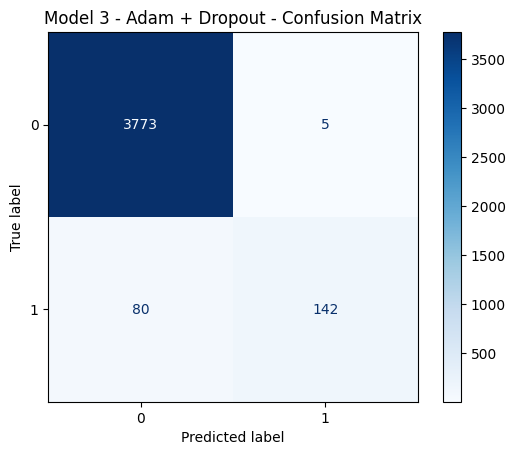

In [ ]:
metrics = evaluate_model(
    model=model_3,
    X=X_val,
    y=y_val,
    model_name="Model 3 - Adam + Dropout"
)

In [ ]:
# Store Results

results_df.loc[len(results_df)] = [
    "Model 3",
    metrics["Accuracy"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["F1 Score"],
    metrics["ROC AUC"]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.99150,0.939252,0.905405,0.922018,0.964776
1,Model 2,0.98925,0.912442,0.891892,0.902050,0.947194
2,Model 3,0.97875,0.965986,0.639640,0.769648,0.931178


**Observations**

* The model achieved 98% validation accuracy, indicating strong overall classification performance.
* It correctly identified 142 out of 222 actual failures, resulting in a Recall of 64%, which is significantly lower than the previous models.
* The model achieved 97% Precision, meaning almost all predicted failures were actual failures, resulting in very few false alarms.
* The confusion matrix shows only 5 false positives but 80 false negatives, indicating that the model became too conservative and missed many actual failures.
* Overall, while dropout reduced false alarms, it significantly reduced the model's ability to detect failures, making it less suitable for this business problem.


Business Perspective

The dropout layer minimized unnecessary inspections but caused many generator failures to be missed, making the model unsuitable for predictive maintenance where early failure detection is the highest priority.

##**Model 4** – Adam + Additional Hidden Layer + Class Weights

In this model, Dropout is removed and Class Weights are introduced to give higher importance to the minority (failure) class while retaining the additional hidden layer and Adam optimizer.

**Add Class weights**

In [ ]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

**Build Model**

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model_4 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [ ]:
history_4 = model_4.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9399 - auc: 0.9366 - loss: 0.2860 - precision: 0.4775 - recall: 0.8727 - val_accuracy: 0.9252 - val_auc: 0.9441 - val_loss: 0.2533 - val_precision: 0.4206 - val_recall: 0.9189
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9737 - auc: 0.9553 - loss: 0.2061 - precision: 0.7057 - recall: 0.9020 - val_accuracy: 0.9615 - val_auc: 0.9484 - val_loss: 0.1835 - val_precision: 0.6000 - val_recall: 0.9189
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9783 - auc: 0.9626 - loss: 0.1831 - precision: 0.7512 - recall: 0.9110 - val_accuracy: 0.9682 - val_auc: 0.9494 - val_loss: 0.1672 - val_precision: 0.6518 - val_recall: 0.9189
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - auc: 0.9680 - loss: 0.1716 - precision: 0.7807 - recall: 0.9099 - val_accuracy: 0.9715 - val_auc: 0.9517 - val_loss: 0.1485 - val_precision: 0.6800 - val_recall: 0.9189
Epoch 5/50
500/500 ━━━━━━━━━━━━━

**Plot Learning Curves**

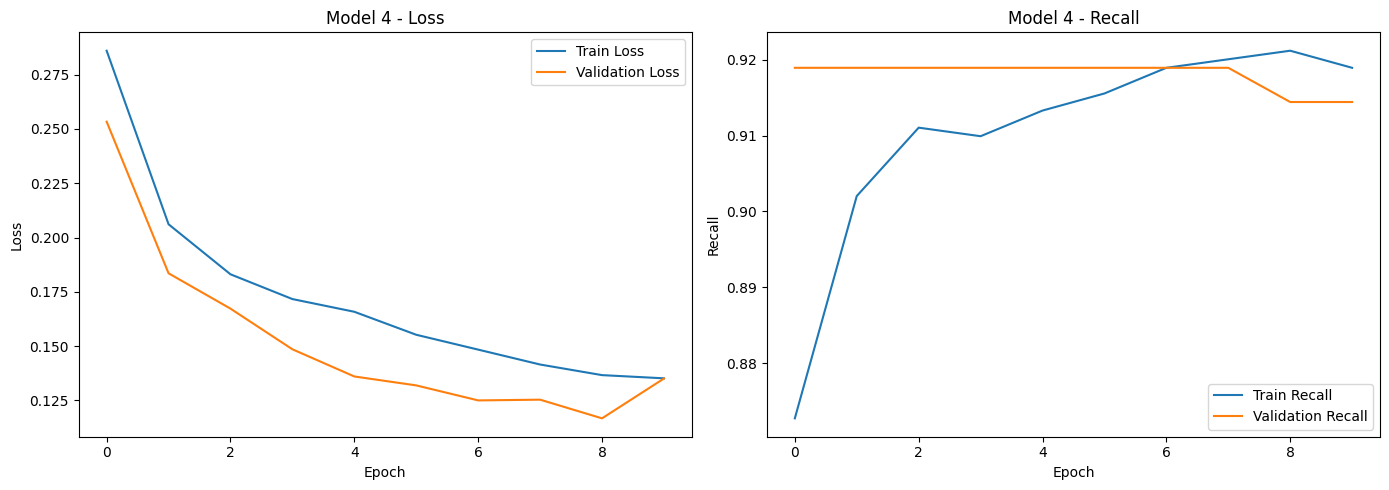

In [ ]:
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_4.history["loss"], label="Train Loss")
plt.plot(history_4.history["val_loss"], label="Validation Loss")
plt.title("Model 4 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history_4.history["recall"], label="Train Recall")
plt.plot(history_4.history["val_recall"], label="Validation Recall")
plt.title("Model 4 - Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**


Model 4 - Additional Hidden Layer + Class Weights
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      3778
           1       0.38      0.92      0.54       222

    accuracy                           0.91      4000
   macro avg       0.69      0.92      0.74      4000
weighted avg       0.96      0.91      0.93      4000



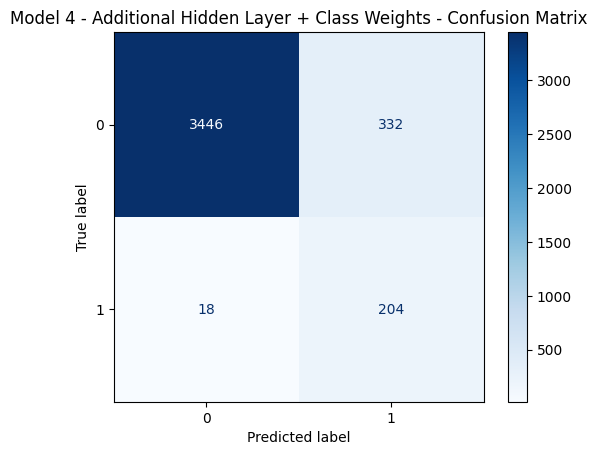

In [ ]:
metrics = evaluate_model(
    model=model_4,
    X=X_val,
    y=y_val,
    model_name="Model 4 - Additional Hidden Layer + Class Weights"
)

In [ ]:
# Store Results
results_df.loc[len(results_df)] = [
    "Model 4",
    metrics["Accuracy"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["F1 Score"],
    metrics["ROC AUC"]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.99150,0.939252,0.905405,0.922018,0.964776
1,Model 2,0.98925,0.912442,0.891892,0.902050,0.947194
2,Model 3,0.97875,0.965986,0.639640,0.769648,0.931178
3,Model 4,0.91250,0.380597,0.918919,0.538259,0.944181


**Observation**

* The model achieved 92% validation accuracy, which is lower than the previous models due to the use of class weights.
* It correctly identified 204 out of 222 actual failures, achieving the highest Recall of 92%, meaning very few failures were missed (18 false negatives).
* However, Precision dropped to 40%, indicating a large number of false alarms.
* The confusion matrix shows 301 false positives and only 18 false negatives, meaning the model prioritized detecting failures at the cost of many unnecessary inspections.
* Overall, class weights significantly improved Recall but substantially increased false positives, resulting in a trade-off between failure detection and inspection costs.


Business Perspective

Class weights maximized failure detection by achieving the highest Recall, but the large number of false alarms would increase inspection costs, making the model less practical for deployment.

##**Model 5**: Adam + Additional Hidden Layer + Dropout + Class Weights

In this model, Dropout layers are added to the previous architecture along with Class Weights to reduce overfitting while maintaining higher importance for the minority (failure) class.

**Build Model**

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model_5 = Sequential([

    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")

])

model_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**


In [ ]:
history_5 = model_5.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8428 - auc: 0.8741 - loss: 0.4560 - precision: 0.2309 - recall: 0.7860 - val_accuracy: 0.9087 - val_auc: 0.9419 - val_loss: 0.2802 - val_precision: 0.3707 - val_recall: 0.9234
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9186 - auc: 0.9344 - loss: 0.3077 - precision: 0.3935 - recall: 0.8637 - val_accuracy: 0.9635 - val_auc: 0.9485 - val_loss: 0.2027 - val_precision: 0.6145 - val_recall: 0.9189
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9377 - auc: 0.9433 - loss: 0.2769 - precision: 0.4673 - recall: 0.8682 - val_accuracy: 0.9660 - val_auc: 0.9452 - val_loss: 0.2050 - val_precision: 0.6344 - val_recall: 0.9144
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9548 - auc: 0.9496 - loss: 0.2471 - precision: 0.5585 - recall: 0.8818 - val_accuracy: 0.9695 - val_auc: 0.9490 - val_loss: 0.1941 - val_precision: 0.6634 - val_recall: 0.9144
Epoch 5/50
500/500 ━━━━━━━━━━━━━

**Plot Learning Curve**


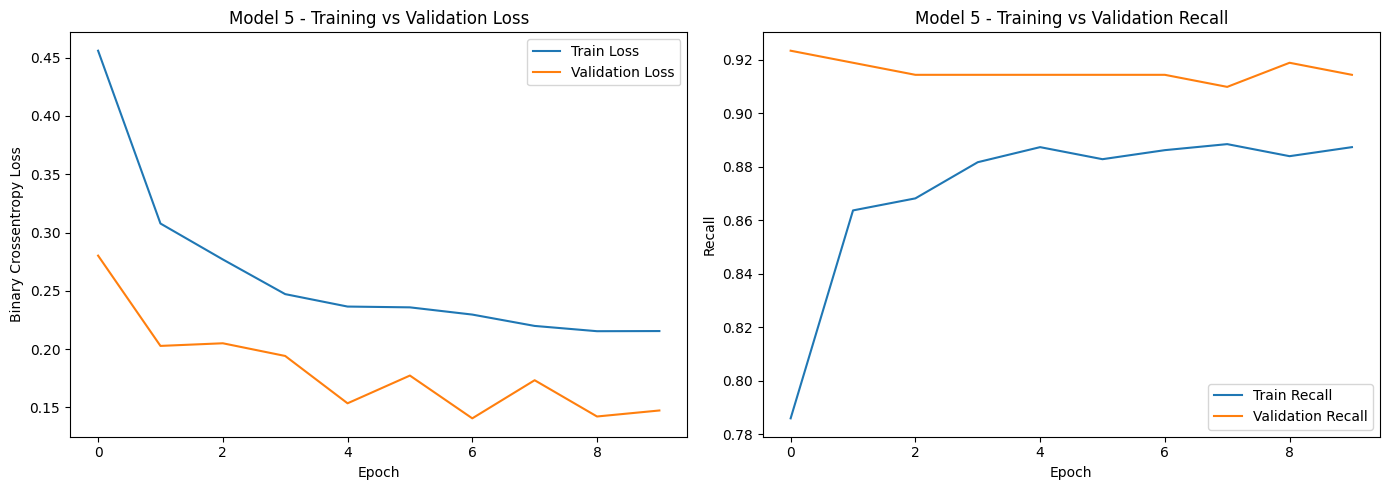

In [ ]:
plt.figure(figsize=(14, 5))

# Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history_5.history["loss"], label="Train Loss")
plt.plot(history_5.history["val_loss"], label="Validation Loss")
plt.title("Model 5 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()

# Training and Validation Recall
plt.subplot(1, 2, 2)
plt.plot(history_5.history["recall"], label="Train Recall")
plt.plot(history_5.history["val_recall"], label="Validation Recall")
plt.title("Model 5 - Training vs Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**


Model 5 - Additional Hidden Layer + Dropout + Class Weights
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      3778
           1       0.32      0.93      0.48       222

    accuracy                           0.89      4000
   macro avg       0.66      0.91      0.71      4000
weighted avg       0.96      0.89      0.91      4000



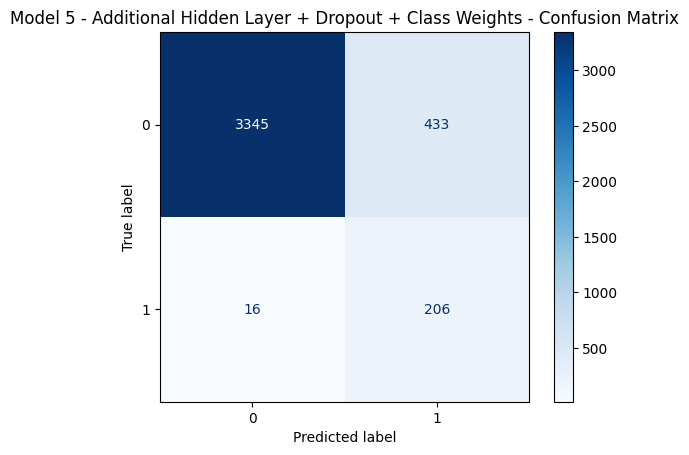

In [ ]:
metrics = evaluate_model(
    model=model_5,
    X=X_val,
    y=y_val,
    model_name="Model 5 - Additional Hidden Layer + Dropout + Class Weights"
)

In [ ]:
# Store Results

results_df.loc[len(results_df)] = [
    "Model 5",
    metrics["Accuracy"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["F1 Score"],
    metrics["ROC AUC"]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.99150,0.939252,0.905405,0.922018,0.964776
1,Model 2,0.98925,0.912442,0.891892,0.902050,0.947194
2,Model 3,0.97875,0.965986,0.639640,0.769648,0.931178
3,Model 4,0.91250,0.380597,0.918919,0.538259,0.944181
4,Model 5,0.88775,0.322379,0.927928,0.478513,0.941865


**Observation**

* The model achieved 89% validation accuracy, reflecting the impact of prioritizing failure detection through class weights.
* It correctly identified 206 out of 222 actual failures, achieving the highest Recall of 93%, meaning very few failures were missed.
* However, Precision dropped to 32%, indicating that many predicted failures were actually healthy generators.
* The confusion matrix shows only 16 false negatives but 433 false positives, meaning the model successfully detects failures at the cost of a large number of unnecessary inspections.
* Overall, combining dropout with class weights further improved Recall but significantly increased false alarms, making the model less balanced than earlier models.


Business Perspective

The model maximizes failure detection by achieving the highest Recall, but the large number of false alarms would lead to excessive inspection costs, reducing its practical value for deployment.

###**Model 6**-Deeper Network + Dropout + Class Weights

In this model, the network architecture is made deeper by increasing the number of hidden layers and neurons and dropout, while retaining the Adam optimizer and Class Weights to evaluate whether a higher-capacity model improves failure detection.

**Build Model**

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
model_6 = Sequential([

    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")

])

model_6.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**


In [ ]:
history_6 = model_6.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8760 - auc: 0.9226 - loss: 0.3496 - precision: 0.2905 - recall: 0.8559 - val_accuracy: 0.9360 - val_auc: 0.9405 - val_loss: 0.2268 - val_precision: 0.4615 - val_recall: 0.9189
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9499 - auc: 0.9452 - loss: 0.2527 - precision: 0.5292 - recall: 0.8773 - val_accuracy: 0.9632 - val_auc: 0.9428 - val_loss: 0.2080 - val_precision: 0.6133 - val_recall: 0.9144
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9619 - auc: 0.9489 - loss: 0.2289 - precision: 0.6087 - recall: 0.8795 - val_accuracy: 0.9548 - val_auc: 0.9462 - val_loss: 0.1924 - val_precision: 0.5559 - val_recall: 0.9189
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9665 - auc: 0.9532 - loss: 0.2121 - precision: 0.6429 - recall: 0.8919 - val_accuracy: 0.9760 - val_auc: 0.9507 - val_loss: 0.1617 - val_precision: 0.7234 - val_recall: 0.9189
Epoch 5/50
500/500 ━━━━━━━━━━━━

**Plot Learning Curve**

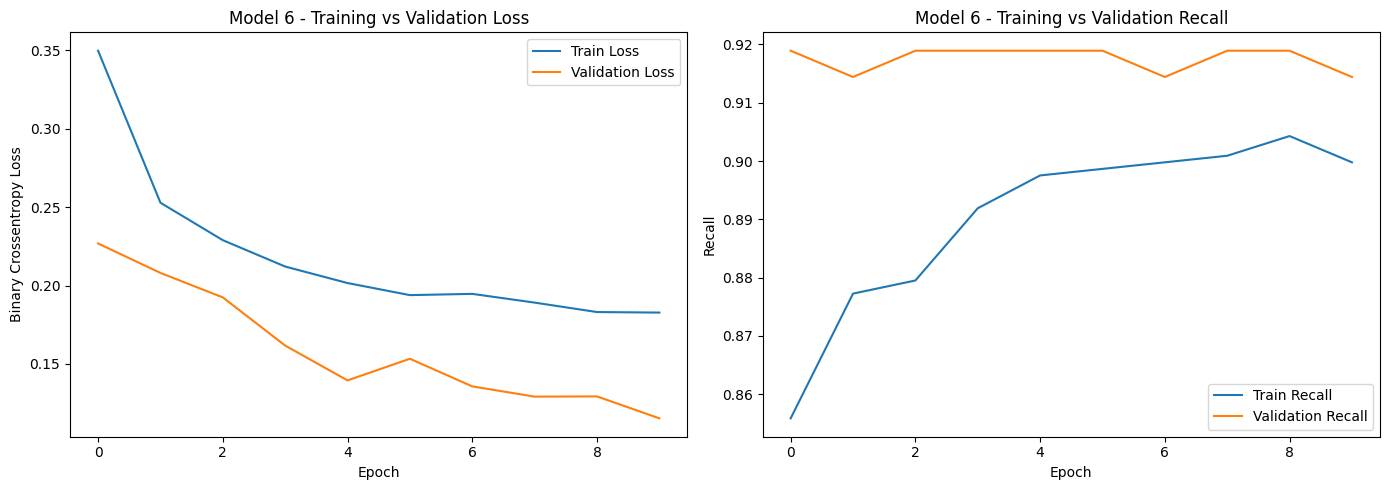

In [ ]:
plt.figure(figsize=(14, 5))

# Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history_6.history["loss"], label="Train Loss")
plt.plot(history_6.history["val_loss"], label="Validation Loss")
plt.title("Model 6 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()

# Training and Validation Recall
plt.subplot(1, 2, 2)
plt.plot(history_6.history["recall"], label="Train Recall")
plt.plot(history_6.history["val_recall"], label="Validation Recall")
plt.title("Model 6 - Training vs Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.tight_layout()
plt.show()

**Evaluate Model**


Model 6 -  Deeper Network + Dropout + Class Weights
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3778
           1       0.85      0.80      0.82       222

    accuracy                           0.98      4000
   macro avg       0.92      0.89      0.91      4000
weighted avg       0.98      0.98      0.98      4000



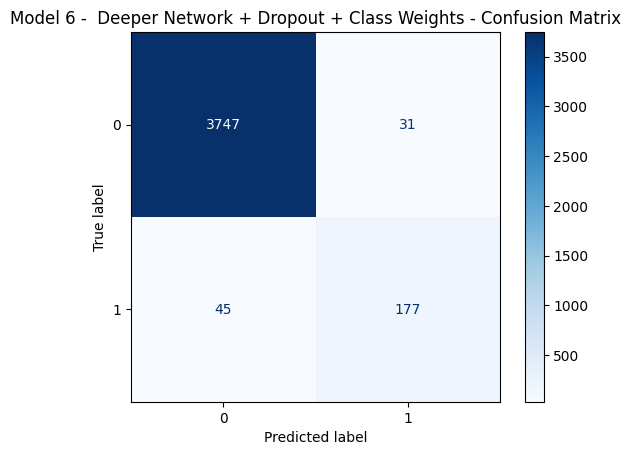

In [ ]:
metrics = evaluate_model(
    model=model_6,
    X=X_val,
    y=y_val,
    model_name="Model 6 -  Deeper Network + Dropout + Class Weights"
)

In [ ]:
# Store Results

results_df.loc[len(results_df)] = [
    "Model 6",
    metrics["Accuracy"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["F1 Score"],
    metrics["ROC AUC"]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.99150,0.939252,0.905405,0.922018,0.964776
1,Model 2,0.98925,0.912442,0.891892,0.902050,0.947194
2,Model 3,0.97875,0.965986,0.639640,0.769648,0.931178
3,Model 4,0.91250,0.380597,0.918919,0.538259,0.944181
4,Model 5,0.88775,0.322379,0.927928,0.478513,0.941865
5,Model 6,0.98100,0.850962,0.797297,0.823256,0.935153


**Observations**

* The model achieved 98% validation accuracy, indicating strong overall classification performance.
* It correctly identified 177 out of 222 actual failures, resulting in a Recall of 80%, which is lower than Models 1, 4, and 5.
* The model achieved 85% Precision, indicating that most predicted failures were actual failures with relatively few false alarms.
* The confusion matrix shows 31 false positives and 45 false negatives, suggesting the deeper network became more conservative and missed more actual failures.
* Overall, increasing the network depth did not improve failure detection and reduced Recall compared to simpler models.

Business Insight:

The deeper network reduced false alarms but missed more generator failures, making it less suitable for predictive maintenance where detecting failures early is the primary business objective.

**Comparison Table**

| **Model**                                              | **Recall** | **Precision** | **False Negatives** | **False Positives** | **Remarks**                                                                                            |
| ------------------------------------------------------ | :--------: | :-----------: | :-----------------: | :-----------------: | ------------------------------------------------------------------------------------------------------ |
| **Baseline – SGD**                                     |  **0.85**  |    **0.75**   |        **33**       |        **62**       | Good baseline performance with scope to improve failure detection.                                     |
| **Model 1 – Adam**                                     |  **0.91**  |    **0.94**   |        **21**       |        **13**       | **Best overall balance between Recall and Precision; recommended final model.**                        |
| **Model 2 – Additional Hidden Layer**                  |  **0.89**  |    **0.91**   |        **24**       |        **19**       | Additional hidden layer did not improve performance over Model 1.                                      |
| **Model 3 – Adam + Dropout**                           |  **0.64**  |    **0.97**   |        **80**       |        **5**        | Very high Precision but significantly increased missed failures due to low Recall.                     |
| **Model 4 – Hidden Layer + Class Weights**             |  **0.92**  |    **0.38**   |        **18**       |       **332**       | Highest Recall but generated a very large number of false positives.                                   |
| **Model 5 – Hidden Layer + Dropout + Class Weights**   |  **0.93**  |    **0.32**   |        **16**       |       **433**       | Highest Recall but excessive false alarms make it less practical for deployment.                       |
| **Model 6 – Deeper Network + Dropout + Class Weights** |  **0.80**  |    **0.85**   |        **45**       |        **31**       | High Precision but lower Recall; deeper network did not improve failure detection over simpler models. |


#Model Selection (Based on Validation Results)

Based on the validation results, Models 1, 4, and 5 were selected as candidate models for evaluation on the unseen test dataset. While Models 4 and 5 were chosen for their superior Recall and alignment with the business objective of minimizing missed failures, Model 1 was selected for its balanced performance across all evaluation metrics. The final model will be chosen after comparing their performance on the independent test dataset to ensure good generalization and practical business value.

1. **Model 5** – Highest Recall (Primary Business Objective)

Reason for Selection

* Achieved the highest Recall (92.79%) among all models.
* Recorded the lowest number of False Negatives, meaning the fewest generator failures were missed.
* Best aligns with the business objective of minimizing costly generator replacements.
* Selected to evaluate whether its high Recall can be maintained on unseen test data while keeping false positives at an acceptable level

2. **Model 4** – High Recall with Better Balance

Reason for Selection

* Achieved a high Recall (91.89%), very close to Model 5.
* Provided better Precision (38.06%) than Model 5.
* Offers a better trade-off between detecting failures and reducing unnecessary inspections.
* Selected to determine whether it generalizes better than Model 5 on unseen data.

3. **Model 1** – Best Balanced Model

Reason for Selection

* Achieved an excellent balance of Recall (90.54%), Precision (93.93%), F1-score (92.20%), and ROC-AUC (0.9648).
* Produced the highest overall classification performance among the balanced models.
* Generated significantly fewer false alarms while maintaining high failure detection.
* Selected to verify whether a balanced model performs better than high-Recall models on the test dataset.

In [ ]:
print(results_df.columns)

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'], dtype='object')


In [ ]:
results_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score", 'ROC AUC'],
    color="green"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Model 1,0.991500,0.939252,0.905405,0.922018,0.964776
1,Model 2,0.989250,0.912442,0.891892,0.902050,0.947194
2,Model 3,0.978750,0.965986,0.639640,0.769648,0.931178
3,Model 4,0.912500,0.380597,0.918919,0.538259,0.944181
4,Model 5,0.887750,0.322379,0.927928,0.478513,0.941865
5,Model 6,0.981000,0.850962,0.797297,0.823256,0.935153


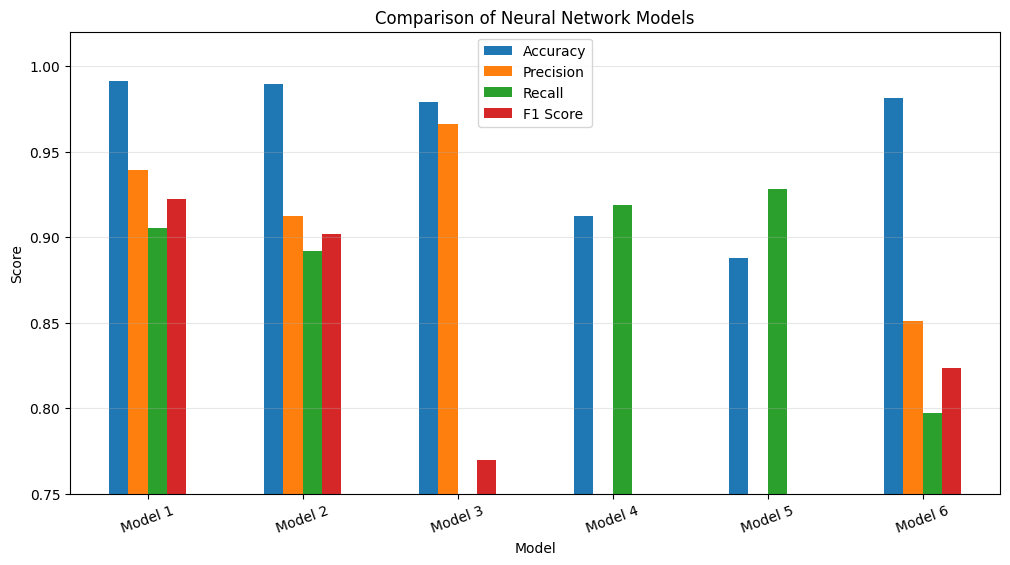

In [ ]:
metrics = ["Accuracy","Precision","Recall","F1 Score"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Neural Network Models")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.ylim(0.75,1.02)

plt.grid(axis="y",alpha=0.3)

plt.show()

#**Test data evaluation**

### Load the Test Dataset

In [ ]:
test_data = pd.read_csv('/content/drive/MyDrive/Test.csv')

In [ ]:
test_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,-5.122874,1.017021,4.818549,3.269001,-2.984330,1.387370,2.032002,-0.511587,-1.023069,7.338733,-2.242244,0.155489,2.053786,-2.772273,1.851369,-1.788696,-0.277282,-1.255143,-3.832886,-1.504542,1.586765,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,1.796544,0.410490,0.638328,-1.389600,-1.883410,-5.017922,-3.827238,2.418060,1.762285,-3.242297,-3.192960,1.857454,-1.707954,0.633444,-0.587898,0.083683,3.013935,-0.182309,0.223917,0.865228,-1.782158,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,-4.928214,3.565070,-0.449329,-0.656246,-0.166537,-1.630207,2.291865,2.396492,0.601278,1.793534,-2.120238,0.481968,-0.840707,1.790197,1.874395,0.363930,-0.169063,-0.483832,-2.118982,-2.156586,2.907291,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,-5.578345,-0.850662,2.590525,0.767418,-2.390809,-2.341961,0.571875,-0.933751,0.508677,1.210715,-3.259524,0.104587,-0.658875,1.498107,1.100305,4.142988,-0.248446,-1.136516,-5.355810,-4.545931,3.808667,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,-0.530016,1.374544,-0.650941,-1.679466,-0.379220,-4.443143,3.893857,-0.607640,2.944931,0.367233,-5.789081,4.597528,4.450264,3.224941,0.396701,0.247765,-2.362047,1.079378,-0.473076,2.242810,-3.591421,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [ ]:
print(test_data.shape)



(5000, 41)


In [ ]:
print(f"Number of Rows    : {test_data.shape[0]}")
print(f"Number of Columns : {test_data.shape[1]}")

Number of Rows    : 5000
Number of Columns : 41


In [ ]:
test_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

In [ ]:
test_data.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observations**

- The test dataset contains 5,000 observations with the same predictor variables as the training dataset.
- Missing values are checked before applying the preprocessing steps.

### Handle Missing values

In [ ]:
test_data["V1"] = test_data["V1"].fillna(data["V1"].median())

test_data["V2"] = test_data["V2"].fillna(data["V2"].median())

Do not recalculate medians from the test data. Use the statistics from the training dataset (data) to avoid data leakage.

### Separate Features and Target

In [ ]:
X_test = test_data.drop("Target", axis=1)

y_test = test_data["Target"]

### Scale the Test Data

In [ ]:
X_test_scaled = scaler.transform(X_test)

### Generate Predictions on Test Data

Instead of repeating the same evaluation code three times, create a reusable function.

In [ ]:
def evaluate_test_model(model, model_name, X_test_scaled, y_test, results_df, threshold=0.45):

    # Predict probabilities
    y_test_prob = model.predict(X_test_scaled)

    # Convert probabilities to class labels
    y_test_pred = (y_test_prob > threshold).astype(int)

    # Flatten arrays
    y_test_prob = y_test_prob.ravel()
    y_test_pred = y_test_pred.ravel()

    # Classification Report
    print("="*70)
    print(model_name)
    print("="*70)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_test_pred))

    # Metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    print(f"Accuracy : {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")
    print(f"ROC AUC  : {test_auc:.4f}")

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"{model_name} - Test Confusion Matrix")
    plt.show()

    # Validation vs Test Comparison
    comparison_df = pd.DataFrame({
        "Dataset": ["Validation", "Test"],
        "Accuracy": [
            results_df.loc[results_df["Model"] == model_name, "Accuracy"].values[0],
            test_accuracy
        ],
        "Precision": [
            results_df.loc[results_df["Model"] == model_name, "Precision"].values[0],
            test_precision
        ],
        "Recall": [
            results_df.loc[results_df["Model"] == model_name, "Recall"].values[0],
            test_recall
        ],
        "F1 Score": [
            results_df.loc[results_df["Model"] == model_name, "F1 Score"].values[0],
            test_f1
        ],
        "ROC AUC": [
            results_df.loc[results_df["Model"] == model_name, "ROC AUC"].values[0],
            test_auc
        ]
    })

    print("\nValidation vs Test Performance\n")
    display(comparison_df)

    return {
        "Model": model_name,
        "Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall,
        "F1 Score": test_f1,
        "ROC AUC": test_auc
    }

###**Model 1**

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 1

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4718
           1       0.49      0.87      0.63       282

    accuracy                           0.94      5000
   macro avg       0.74      0.91      0.80      5000
weighted avg       0.96      0.94      0.95      5000

Accuracy : 0.9418
Precision: 0.4909
Recall   : 0.8652
F1 Score : 0.6264
ROC AUC  : 0.9305


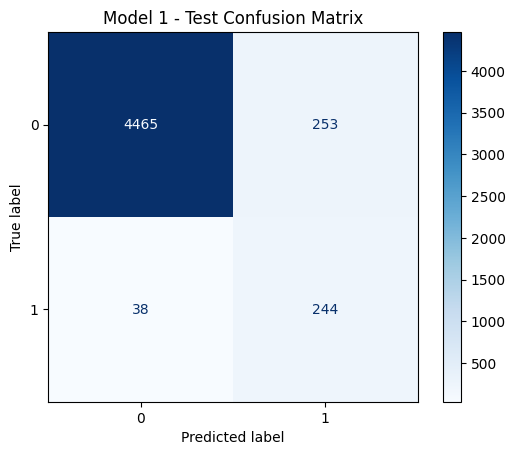


Validation vs Test Performance



,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Validation,0.9915,0.939252,0.905405,0.922018,0.964776
1,Test,0.9418,0.490946,0.865248,0.626444,0.930509


In [ ]:
model1_results = evaluate_test_model(
    model=model_1,
    model_name="Model 1",
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    results_df=results_df
)

**Observations**

* The model achieved 94.18% test accuracy, indicating strong overall performance on unseen data.
* It correctly identified 244 out of 282 actual failures, resulting in a Recall of 86.52%, showing that the model successfully detects most generator failures.
* The Precision decreased to 49.09% on the test dataset, indicating that approximately half of the predicted failures were actual failures, leading to some additional inspections.
* The confusion matrix shows 253 false positives and 38 false negatives, demonstrating a reasonable trade-off between detecting failures and avoiding unnecessary maintenance.
* Compared to the validation results, the model experienced a small drop in Recall (90.54% → 86.52%) and ROC-AUC (0.9648 → 0.9305), indicating that it generalizes well to unseen data.

**Validation vs Test Comparison**

* The model maintained high Recall on the test dataset with only a 4% decrease, demonstrating good generalization.
* Although Precision and F1-score decreased on the test data, the model continued to provide strong discrimination between failure and non-failure cases (ROC-AUC = 0.9305).
* The overall performance indicates that the model is robust and capable of identifying failures on unseen data while maintaining a reasonable balance between missed failures and false alarms.

###**Model 4**

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 4

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.41      0.58      4718
           1       0.09      0.94      0.16       282

    accuracy                           0.44      5000
   macro avg       0.54      0.68      0.37      5000
weighted avg       0.94      0.44      0.56      5000

Accuracy : 0.4396
Precision: 0.0872
Recall   : 0.9433
F1 Score : 0.1596
ROC AUC  : 0.9258


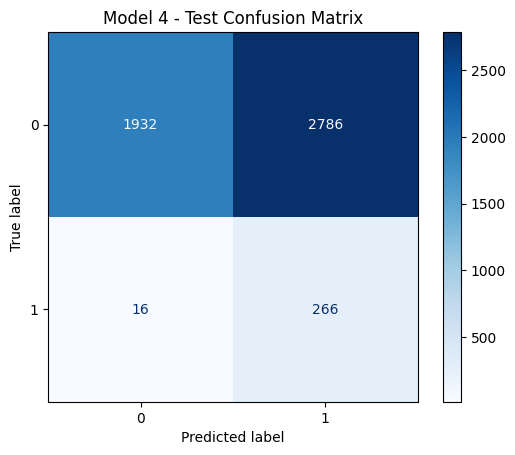


Validation vs Test Performance



,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Validation,0.9125,0.380597,0.918919,0.538259,0.944181
1,Test,0.4396,0.087156,0.943262,0.159568,0.925819


In [ ]:
model4_results = evaluate_test_model(
    model=model_4,
    model_name="Model 4",
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    results_df=results_df
)

**Test Data Observations**

* The model achieved 43.96% test accuracy, indicating poor overall performance on unseen data.
* It correctly identified 266 out of 282 actual failures, achieving the highest Recall of 94.33%, meaning very few generator failures were missed.
* However, the Precision dropped to just 8.72%, indicating that the majority of predicted failures were actually healthy generators.
* The confusion matrix shows only 16 false negatives but an extremely high 2,786 false positives, resulting in a large number of unnecessary maintenance inspections.
* Compared to the validation results, the model maintained its high Recall (91.89% → 94.33%) but experienced a substantial drop in Precision (38.06% → 8.72%) and F1-score (53.83% → 15.96%), indicating poor generalization in terms of false alarm control.

**Validation vs Test Comparison**

* The model successfully maintained very high Recall, demonstrating its ability to detect almost all generator failures.
* However, the dramatic reduction in Precision and F1-score shows that it generated an excessive number of false alarms on the test dataset.
* While the ROC-AUC (0.9258) remained reasonably good, the extremely high false positive rate makes the model impractical for real-world deployment.

###**Model 5**

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Model 5

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.37      0.54      4718
           1       0.08      0.94      0.15       282

    accuracy                           0.40      5000
   macro avg       0.54      0.65      0.34      5000
weighted avg       0.94      0.40      0.51      5000

Accuracy : 0.3996
Precision: 0.0815
Recall   : 0.9397
F1 Score : 0.1501
ROC AUC  : 0.9112


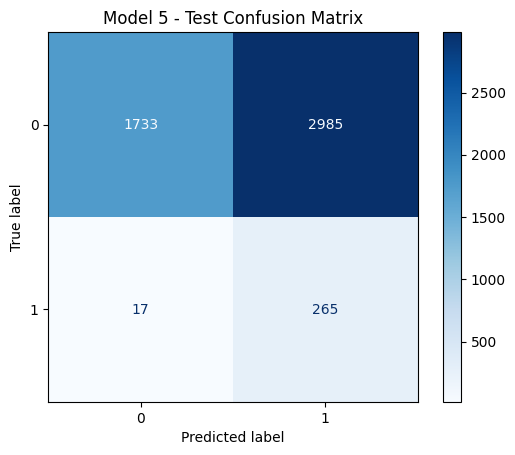


Validation vs Test Performance



,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Validation,0.88775,0.322379,0.927928,0.478513,0.941865
1,Test,0.39960,0.081538,0.939716,0.150057,0.911191


In [ ]:
model5_results = evaluate_test_model(
    model=model_5,
    model_name="Model 5",
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    results_df=results_df
)

**Test Data Observations**

* The model achieved 39.96% test accuracy, indicating poor overall performance on unseen data.
* It correctly identified 265 out of 282 actual failures, resulting in the highest Recall of 93.97%, meaning very few generator failures were missed.
* However, the Precision dropped to just 8.15%, indicating that most predicted failures were actually healthy generators.
* The confusion matrix shows only 17 false negatives but an extremely high 2,985 false positives, leading to a very large number of unnecessary maintenance inspections.
* Compared to the validation results, the model maintained its high Recall (92.79% → 93.97%) but experienced a significant drop in Precision (32.24% → 8.15%), F1-score (47.85% → 15.01%), and ROC-AUC (0.9419 → 0.9112), indicating poor generalization in terms of balancing failure detection and false alarms.

**Validation vs Test Comparison**

* The model consistently maintained very high Recall, demonstrating its ability to detect almost all generator failures.
* However, the substantial decrease in Precision and F1-score shows that it generated an excessive number of false positives on the test dataset.
* Although the model aligns well with the objective of minimizing missed failures, its high false alarm rate makes it impractical for real-world deployment.

##**Final Comparison**

After evaluating the shortlisted models (Model 1, Model 4, and Model 5) on the unseen test dataset, I recommend Model 1 as the final model.

| Metric    |    Model 1 |    Model 4 |    Model 5 |
| --------- | ---------: | ---------: | ---------: |
| Accuracy  | **94.18%** |     43.96% |     39.96% |
| Precision | **49.09%** |      8.72% |      8.15% |
| Recall    |     86.52% | **94.33%** | **93.97%** |
| F1 Score  | **62.64%** |     15.96% |     15.01% |
| ROC-AUC   | **0.9305** |     0.9258 |     0.9112 |


Why Model 1?

Although Models 4 and 5 achieved higher Recall, they did so by predicting a very large number of healthy generators as failures.

| Model       | False Negatives | False Positives |
| ----------- | --------------: | --------------: |
| **Model 1** |          **38** |         **253** |
| Model 4     |          **16** |        **2786** |
| Model 5     |          **17** |        **2985** |

* Model 4 detects 22 more failures than Model 1 but generates 2,533 additional false alarms.
* Model 5 detects 21 more failures than Model 1 but generates 2,732 additional false alarms.

This means Models 4 and 5 would require thousands of unnecessary inspections for only a small improvement in failure detection.

##**Final Recommendation**

Six neural network models were developed using different architectures, optimizers, dropout, and class weights to improve predictive maintenance performance. Based on the validation results, Models 1, 4, and 5 were shortlisted and evaluated on the unseen test dataset.

After comparing their test performance, Model 1 (Adam Optimizer) was selected as the final model. While Models 4 and 5 achieved slightly higher Recall, they generated a very large number of false positives, leading to excessive and unnecessary maintenance inspections. In contrast, Model 1 achieved the best overall balance between Recall (86.52%), Precision (49.09%), F1-score (62.64%), and ROC-AUC (0.9305), while maintaining a much lower number of false positives.

Overall, Model 1 provides the most practical solution for ReneWind, effectively detecting generator failures while keeping inspection costs under control.

##**Business Insights & Recommendations**

* Deploy Model 1 as the final predictive maintenance model, as it provides the best balance between identifying generator failures and minimizing unnecessary inspections, making it operationally practical.
* Adopt predictive maintenance instead of reactive maintenance by scheduling inspections and repairs for generators predicted to fail. This can reduce unexpected breakdowns, maintenance downtime, and expensive generator replacement costs.
* Prioritize high-risk turbines identified by the model so that maintenance teams can focus on the most critical equipment first, leading to better utilization of maintenance resources.
* Reduce operational costs by minimizing emergency repairs and unplanned outages. Although some false alarms remain, inspection costs are considerably lower than the cost of replacing failed generators.
* Continuously monitor and retrain the model using newly collected sensor data to improve prediction accuracy and ensure the model adapts to changing operating conditions and equipment aging.
* Integrate the model into the maintenance workflow so that predictions automatically trigger maintenance alerts, enabling timely decision-making and improving the overall reliability and availability of wind turbines.

##**Key Takeaways**

* Multiple neural network models were developed and evaluated using different optimizers, hidden layers, dropout, and class weights to improve failure prediction.
* Models with class weights achieved the highest Recall but produced a large number of false positives, making them less practical for real-world deployment.
* Model 1 (Adam Optimizer) provided the best balance between Recall, Precision, F1-score, and ROC-AUC, while maintaining a manageable number of false alarms.
* The model generalized well on the unseen test dataset, demonstrating its ability to reliably predict generator failures on new data.
* Deploying Model 1 can help ReneWind identify potential failures early, reduce costly generator replacements, optimize maintenance scheduling, and improve the overall reliability and operational efficiency of wind turbines.
* Regular retraining with new sensor data and periodic threshold tuning can further enhance the model's long-term performance and adapt it to changing operating conditions.